In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import LambdaCDM
from matplotlib.lines import Line2D
from scipy.stats import chi2
import emcee
import corner
from pathlib import Path

In [7]:
metadata = pd.read_csv("Pantheon+SH0ES.dat", sep=r"\s+")

metadata["MU"] = metadata["MU_SH0ES"]
metadata["MUERR"] = metadata["MU_SH0ES_ERR_DIAG"]
metadata["MUERR_VPEC"] = metadata["m_b_corr_err_VPEC"]
metadata["LENSDMUERR"] = 0.055 * metadata["zHD"]

# Construct a reference-model distance modulus for plotting/residual figures
reference_cosmology = LambdaCDM(H0=73.04, Om0=0.3, Ode0=0.7)
metadata["MUMODEL"] = reference_cosmology.distmod(metadata["zHD"].clip(lower=1e-6)).value

dmB_dx0 = -2.5 / (np.log(10.0) * metadata["x0"])
metadata["COV_mB_x1"] = dmB_dx0 * metadata["COV_x1_x0"]
metadata["COV_mB_c"] = dmB_dx0 * metadata["COV_c_x0"]

metadata = metadata.replace([-9, -999], np.nan)

## Define sample selections

- **`mass_cut`**: Median values used to split the mass sample.
- **`low_z` / `high_z`**: Low- and high-redshift supernovae.
- **`low_mass` / `high_mass`**: Host galaxy stellar mass categories.

In [8]:
mass_cut = 10.0

low_z = metadata["zHD"] < 0.1
high_z = metadata["zHD"] >= 0.1

low_mass = metadata["HOST_LOGMASS"] < mass_cut
high_mass = metadata["HOST_LOGMASS"] >= mass_cut

In [9]:
all_samples = {
    "all": metadata,
    }

z_samples = {
    "Low redshift": metadata[low_z],
    "High redshift": metadata[high_z],
    }

z_m_samples = {
    "Low redshift, low-mass hosts": metadata[low_z & low_mass],
    "Low redshift, high-mass hosts": metadata[low_z & high_mass],
    "High redshift, low-mass hosts": metadata[high_z & low_mass],
    "High redshift, high-mass hosts": metadata[high_z & high_mass],
    }

## Hubble diagram for the full sample

Plots distance modulus (**`MU`**) versus redshift (**`zHD`**) for every supernova.

- **`MU`** is the measured distance modulus.
- **`MUERR`** provides the uncertainty on each measurement.
- **`MUMODEL`** is the predicted distance modulus from the reference cosmological model.

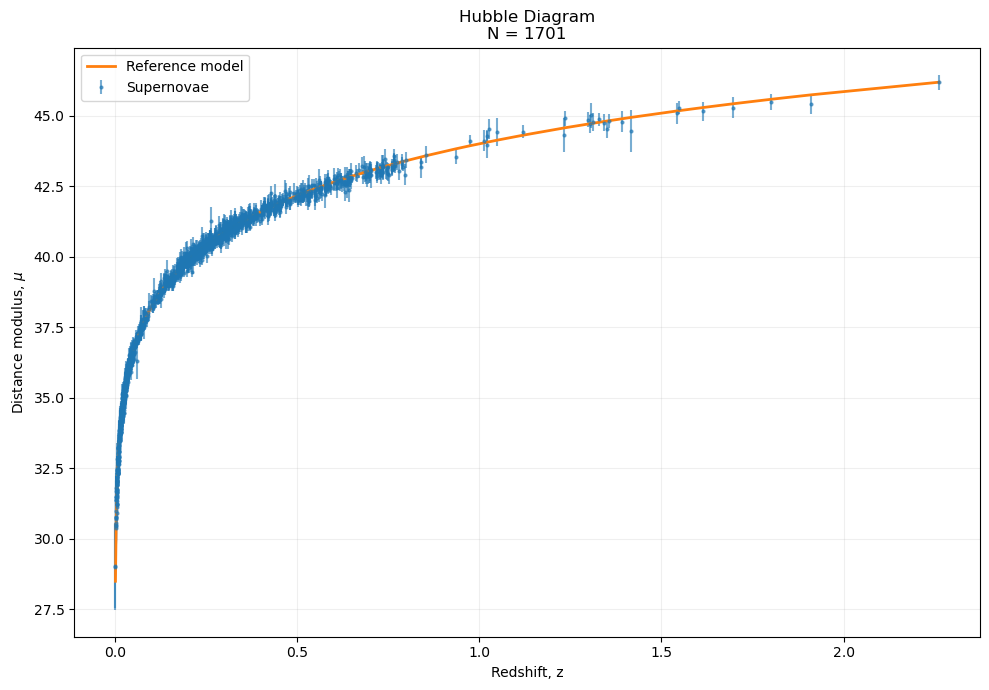

In [10]:
plt.figure(figsize=(10, 7))

sample = all_samples["all"]

plt.errorbar(
    sample["zHD"],
    sample["MU"],
    yerr=sample["MUERR"],
    fmt=".",
    markersize=4,
    alpha=0.6,
    capsize=0,
    label="Supernovae"
)

model = sample.sort_values("zHD")

plt.plot(
    model["zHD"],
    model["MUMODEL"],
    linewidth=2,
    label="Reference model"
)

plt.xlabel("Redshift, z")
plt.ylabel(r"Distance modulus, $\mu$")
plt.title(f"Hubble Diagram\nN = {len(sample)}")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

## Compare low- and high-redshift samples

Creates Hubble diagrams for the low- and high-redshift subsets to compare how the observations agree with the reference cosmology.

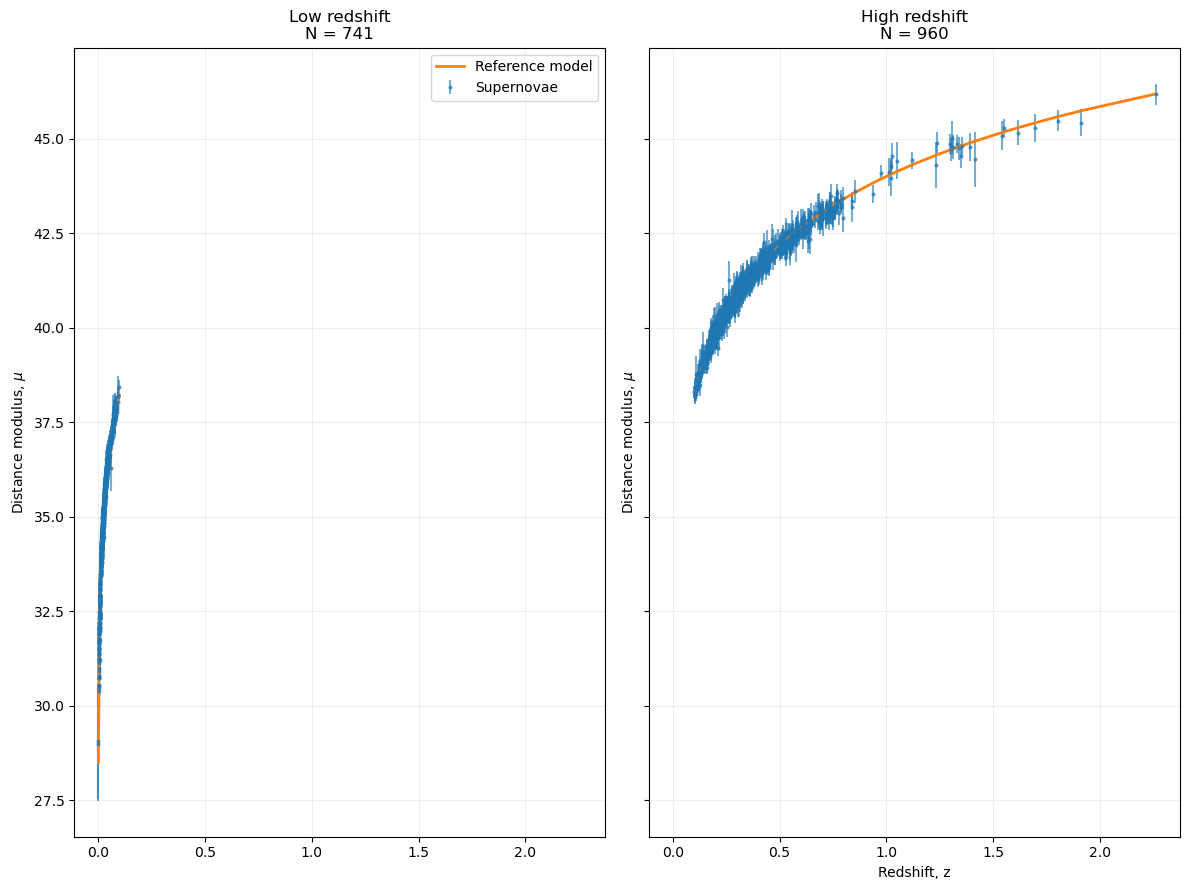

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

for ax, (title, sample) in zip(axes.flat, z_samples.items()):

    # Plot measured distance moduli.
    ax.errorbar(
        sample["zHD"],
        sample["MU"],
        yerr=sample["MUERR"],
        fmt=".",
        markersize=4,
        alpha=0.6,
        capsize=0,
        label="Supernovae"
    )

    # Plot the reference cosmological model.
    model = sample.sort_values("zHD")

    ax.plot(
        model["zHD"],
        model["MUMODEL"],
        linewidth=2,
        label="Reference model"
    )

    ax.set_title(f"{title}\nN = {len(sample)}")
    ax.set_ylabel(r"Distance modulus, $\mu$")
    ax.grid(alpha=0.2)


axes[1].set_xlabel("Redshift, z")
axes[0].legend()


plt.tight_layout()
plt.show()

## Compare host galaxy mass

Creates Hubble diagrams split by both redshift and host galaxy stellar mass, allowing any mass-dependent trends to be visually inspected.

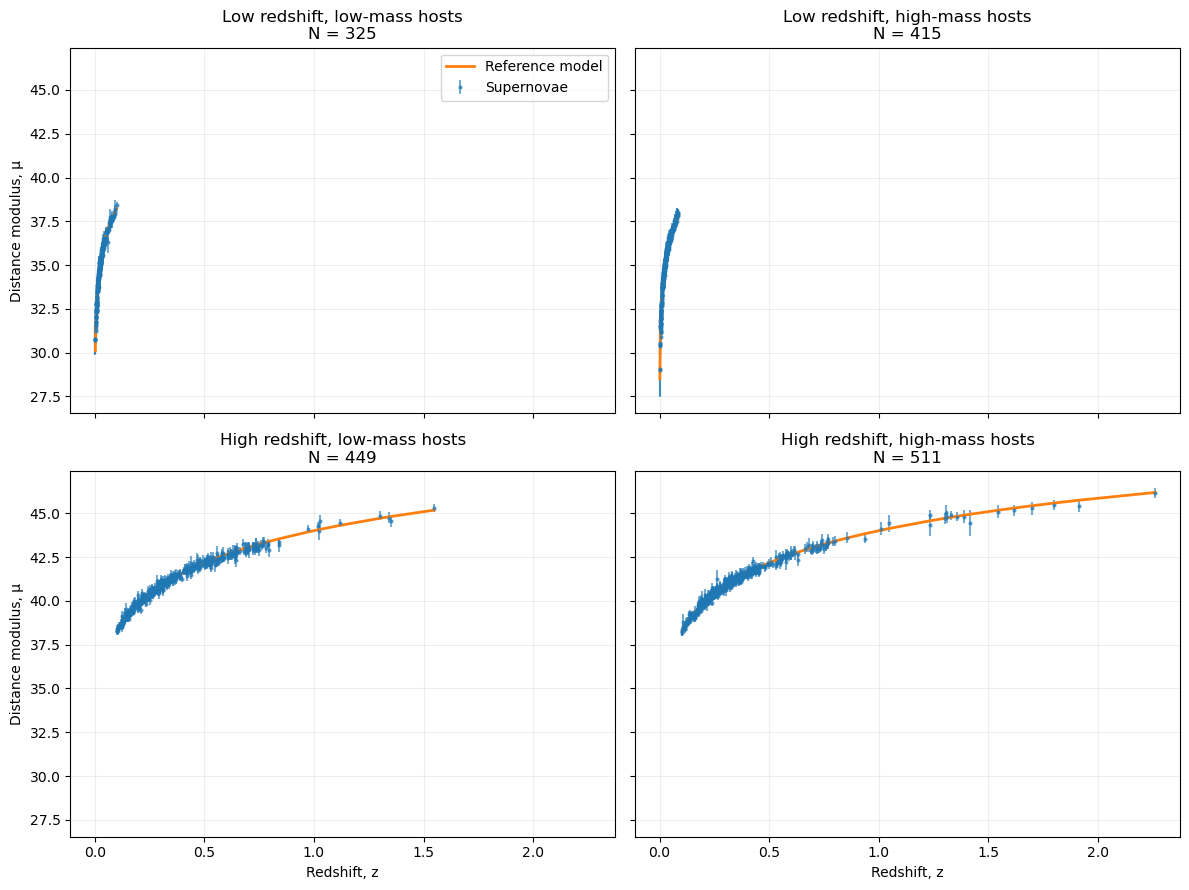

In [12]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
    sharex=True,
    sharey=True
)

for ax, (title, sample) in zip(axes.flat, z_m_samples.items()):

    # Plot measured distance moduli.
    ax.errorbar(
        sample["zHD"],
        sample["MU"],
        yerr=sample["MUERR"],
        fmt=".",
        markersize=4,
        alpha=0.6,
        capsize=0,
        label="Supernovae"
    )

    # Plot the reference cosmological model.
    model = sample.sort_values("zHD")

    ax.plot(
        model["zHD"],
        model["MUMODEL"],
        linewidth=2,
        label="Reference model"
    )

    ax.set_title(f"{title}\nN = {len(sample)}")
    ax.grid(alpha=0.2)

axes[0, 0].set_ylabel("Distance modulus, μ")
axes[1, 0].set_ylabel("Distance modulus, μ")

axes[1, 0].set_xlabel("Redshift, z")
axes[1, 1].set_xlabel("Redshift, z")

axes[0, 0].legend()

plt.tight_layout()
plt.show()

In [13]:
def weighted_mean_and_error(values, errors):
    weights = 1.0 / errors**2
    mean = np.average(values, weights=weights)
    error = np.sqrt(1.0 / weights.sum())
    return mean, error

# Cosmological Parameter Fitting

This section contains the MCMC analysis. The workflow is organized in execution order:

1. Define the likelihood, priors, and helper functions.
2. Build the non-clipped analysis samples.
3. Run all non-clipped 5D fits.
4. Use the non-clipped 5D fits to define the 2.5-sigma clipped samples.
5. Run the clipped fits.
6. Make the final Hubble diagrams.

### Covariance Matrix

The light-curve fitter simultaneously determines three light-curve parameters:

* $x_0$, which is converted into the apparent magnitude (m_B),
* $x_1$, the stretch parameter,
* $c$, the color parameter.

Because these parameters are fitted simultaneously, their uncertainties are generally correlated. These correlations are described by the covariance matrix

$$
\begin{pmatrix}
\sigma_{x_0}^2 &
\mathrm{Cov}(x_0,x_1) &
\mathrm{Cov}(x_0,c) \\
\mathrm{Cov}(x_1,x_0) &
\sigma_{x_1}^2 &
\mathrm{Cov}(x_1,c) \\
\mathrm{Cov}(c,x_0) &
\mathrm{Cov}(c,x_1) &
\sigma_c^2
\end{pmatrix}.
$$

The diagonal elements are the variances of the fitted parameters, while the off-diagonal elements are the covariances, which quantify how the uncertainties in two parameters are correlated.

The metadata file stores the off-diagonal covariance terms as the columns

* `COV_x1_x0`,
* `COV_c_x0`,
* `COV_x1_c`.

Since the cosmological analysis uses the apparent magnitude $m_B$ rather than the normalization parameter $x_0$, the covariance terms involving $x_0$ are transformed using

$$
m_B = -2.5\log_{10}(x_0) + \mathrm{constant},
$$

whose derivative is

$$
\frac{dm_B}{dx_0} = -\frac{2.5}{x_0\ln10}.
$$

Applying standard uncertainty propagation gives

$$
\mathrm{Cov}(m_B,x_1) = \frac{dm_B}{dx_0} \mathrm{Cov}(x_0,x_1),
$$

and

$$
\mathrm{Cov}(m_B,c) = \frac{dm_B}{dx_0} \mathrm{Cov}(x_0,c).
$$

These transformed covariance terms are then used when propagating the uncertainty in the reconstructed distance modulus,

$$
\mu_{\rm obs} = m_B - M_B + \alpha x_1 - \beta c + \gamma HM,
$$

ensuring that the likelihood correctly accounts for the correlated uncertainties in the light-curve parameters.


In [14]:
# FIXED
H_0 = 70.0
sigma_int = 0.10

def log_prior(theta):
    """
    Defines which parameter values the MCMC is allowed to explore.
    Returns:
        0.0      for an allowed parameter combination
        -np.inf  for a forbidden parameter combination
    Because the posterior is evaluated in logarithmic form, returning -np.inf makes the posterior probability exactly zero.
    """
    nparam = len(theta)
    
    if nparam == 5:
        M_B, Omega_M, Omega_Lambda, alpha, beta = theta
        if (
            -20.5 < M_B < -18.0
            and 0.0 < Omega_M < 1.5 
            and -1.5 <= Omega_Lambda < 1.5
            and 0.0 < alpha < 0.5
            and 0.0 < beta < 6.0
        ):
            return 0.0
        else:
            return -np.inf

    elif nparam == 6:
        M_B, Omega_M, Omega_Lambda, alpha, beta, gamma = theta
        if (
            -20.5 < M_B < -18.0
            and 0.0 < Omega_M < 1.5 
            and -1.5 <= Omega_Lambda < 1.5
            and 0.0 < alpha < 0.5
            and 0.0 < beta < 6.0
            and -0.5 < gamma < 0.5
        ):
            return 0.0
        else:
            return -np.inf
    else:
        raise ValueError("Unexpected size? len(theta) should be 5 or 6")    


def log_likelihood(theta, data):
    """
    Compares the measured distance moduli with the distance moduli predicted by the proposed cosmological parameters.
    Theta contains the proposed cosmological parameters.
    Data is a tuple containing:
        redshift
        observed distance modulus
        distance-modulus uncertainty
    """
    nparam = len(theta)

    if nparam == 5:
        M_B, Omega_M, Omega_Lambda, alpha, beta = theta
        (
            redshift,
            mB,
            x1,
            c,
            host_logmass,
            mB_err,
            x1_err,
            c_err,
            cov_mB_x1,
            cov_mB_c,
            cov_x1_c,
            muerr_vpec,
            lensdmuerr
        ) = data
        mu_obs = mB - M_B + alpha*x1 - beta*c
        variance = mB_err**2 + alpha**2*x1_err**2 + beta**2*c_err**2 + 2.0*alpha*cov_mB_x1 - 2.0*beta*cov_mB_c - 2.0*alpha*beta*cov_x1_c + muerr_vpec**2 + lensdmuerr**2 + sigma_int**2

    elif nparam == 6:
        M_B, Omega_M, Omega_Lambda, alpha, beta, gamma = theta
        (
            redshift,
            mB,
            x1,
            c,
            host_logmass,
            mB_err,
            x1_err,
            c_err,
            cov_mB_x1,
            cov_mB_c,
            cov_x1_c,
            muerr_vpec,
            lensdmuerr
        ) = data
        HM = (host_logmass >= mass_cut).astype(float)
        mu_obs = mB - M_B + alpha*x1 - beta*c + gamma*HM
        variance = mB_err**2 + alpha**2*x1_err**2 + beta**2*c_err**2 + 2.0*alpha*cov_mB_x1 - 2.0*beta*cov_mB_c - 2.0*alpha*beta*cov_x1_c + muerr_vpec**2 + lensdmuerr**2 + sigma_int**2
    else:
        raise ValueError("Unexpected size? len(theta) should be 5 or 6")    


    # Construct Astropy LambdaCDM cosmology using the current proposed values of H0, Omega_M, and Omega_Lambda.
    # H0: Present-day Hubble expansion rate in km/s/Mpc.
    # Om0: Present-day matter density parameter Omega_M.
    # Ode0: Present-day dark-energy density parameter Omega_Lambda.
    
    cosmology = LambdaCDM(
        H0=H_0,
        Om0=Omega_M,
        Ode0=Omega_Lambda
    )
    
    with np.errstate(invalid="ignore"):
        mu_pred = cosmology.distmod(redshift).value
    
    if not np.all(np.isfinite(mu_pred)):
        return -np.inf
    
    residuals = mu_obs - mu_pred
    
    if np.any(~np.isfinite(variance)) or np.any(variance <= 0.0):
        return -np.inf
    
    loglike = -0.5 * np.sum(np.log(2.0 * np.pi * variance) + residuals**2 / variance)

    return loglike

def log_posterior(theta, data):
    logpr = log_prior(theta)
    if logpr == -np.inf:
        return logpr
    else:
        return logpr + log_likelihood(theta, data)

def make_data_tuple(sample, nparam):
    if nparam in (5, 6):
        return (
            sample["zHD"].to_numpy(),
            sample["mB"].to_numpy(),
            sample["x1"].to_numpy(),
            sample["c"].to_numpy(),
            sample["HOST_LOGMASS"].to_numpy(),
            sample["mBERR"].to_numpy(),
            sample["x1ERR"].to_numpy(),
            sample["cERR"].to_numpy(),
            sample["COV_mB_x1"].to_numpy(),
            sample["COV_mB_c"].to_numpy(),
            sample["COV_x1_c"].to_numpy(),
            sample["MUERR_VPEC"].to_numpy(),
            sample["LENSDMUERR"].to_numpy()
        )

    else:
        raise ValueError("nparam should be 5 or 6")

def make_starting_positions(initial_guess, nwalkers, random_seed=None):
    rng = np.random.default_rng(random_seed)
    ndim = len(initial_guess)

    if ndim == 5:
        scales = np.array([0.02, 0.02, 0.02, 0.01, 0.10])
    
    elif ndim == 6:
        scales = np.array([0.02, 0.02, 0.02, 0.01, 0.10, 0.01])

    else:
        raise ValueError("initial_guess must contain 5 or 6 parameters")

    positions = initial_guess + scales * rng.normal(size=(nwalkers, ndim))

    for i in range(nwalkers):
        while not np.isfinite(log_prior(positions[i])):
            positions[i] = initial_guess + scales * rng.normal(size=ndim)

    return positions


def run_mcmc(data, initial_guess, nwalkers=32, nsteps=5000, burnin=1000, thin=1, random_seed=None):
    ndim = len(initial_guess)

    if nwalkers < 2 * ndim:
        raise ValueError("nwalkers must be at least twice ndim")

    if burnin >= nsteps:
        raise ValueError("burnin must be smaller than nsteps")

    starting_positions = make_starting_positions(
        initial_guess,
        nwalkers,
        random_seed=random_seed
    )

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_posterior,
        args=(data,),
        threads = 8
    )

    sampler.run_mcmc(
        starting_positions,
        nsteps,
        progress=True
    )

    samples = sampler.get_chain(
        discard=burnin,
        thin=thin,
        flat=True
    )

    return sampler, samples


def summarize_samples(name, samples, filename=None):
    if samples.shape[1] == 5:
        labels = ["M_B", "Omega_M", "Omega_Lambda", "alpha", "beta"]
    elif samples.shape[1] == 6:
        labels = ["M_B", "Omega_M", "Omega_Lambda", "alpha", "beta", "gamma"]
    else:
        raise ValueError("Samples must contain 5 or 6 columns")

    percentiles = np.percentile(samples, [16, 50, 84], axis=0)

    print(f"\n{name}")

    summary = {}
    summary_lines = [name]

    for i, label in enumerate(labels):
        median = percentiles[1, i]
        lower = median - percentiles[0, i]
        upper = percentiles[2, i] - median

        summary[label] = {
            "median": median,
            "minus": lower,
            "plus": upper
        }

        line = f"{label} = {median:.4f} -{lower:.4f} +{upper:.4f}"

        print(line)
        summary_lines.append(line)

    if filename is not None:
        filename = Path(filename)
        filename.parent.mkdir(parents=True, exist_ok=True)

        summary_text = "\n".join(summary_lines)

        with open(filename, "w") as f:
            f.write(summary_text)

    return summary

def get_corner_ranges(samples1, samples2):
    combined = np.vstack([samples1, samples2])
    ranges = []

    for i in range(combined.shape[1]):
        low = np.min(combined[:, i])
        high = np.max(combined[:, i])
        padding = 0.05 * (high - low)

        ranges.append((low - padding, high + padding))

    return ranges

def plot_overlaid_corner(samples_1, samples_2, label_1, label_2, title, color_1, color_2, filename=None):
    
    ndim = samples_1.shape[1]

    if samples_2.shape[1] != ndim:
        raise ValueError("Both sample arrays must have the same number of columns")

    #corner_ranges = get_corner_ranges(samples_1, samples_2)
    
    if ndim == 5:
        parameter_labels = [
            r"$M_B$",
            r"$\Omega_M$",
            r"$\Omega_\Lambda$",
            r"$\alpha$",
            r"$\beta$",
        ]
    
    elif ndim == 6:
        parameter_labels = [
            r"$M_B$",
            r"$\Omega_M$",
            r"$\Omega_\Lambda$",
            r"$\alpha$",
            r"$\beta$",
            r"$\gamma$"
        ]

    else:
        raise ValueError("Samples must contain 5 or 6 columns")
    
    figure = corner.corner(
        samples_1,
        labels=parameter_labels,
        #range=corner_ranges,
        color=color_1,
        levels=(0.683, 0.954),
        plot_datapoints=False,
        plot_density=True,
        fill_contours=False,
        smooth=1.0,
        show_titles=False,
        title_fmt=".3f"
    )

    corner.corner(
        samples_2,
        labels=parameter_labels,
        #range=corner_ranges,
        color=color_2,
        levels=(0.683, 0.954),
        plot_datapoints=False,
        plot_density=True,
        fill_contours=False,
        smooth=1.0,
        show_titles=False,
        fig=figure
    )

    legend_handles = [
        Line2D([0], [0], color=color_1, linewidth=2, label=label_1),
        Line2D([0], [0], color=color_2, linewidth=2, label=label_2)
    ]

    figure.legend(
        handles=legend_handles,
        loc="upper right",
        frameon=False
    )

    figure.suptitle(title, fontsize=14, y=1.02)
    #figure.subplots_adjust(top=0.90)

    if filename is not None:
        figure.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )   
    plt.show()

# DIAGNOSTICS
def plot_x1_diagnostic(sample, M_B, Omega_M, Omega_Lambda, alpha, beta, gamma, color="black", title=r"$x_1$ diagnostic", filename=None):
    data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

    cosmology = LambdaCDM(H0=H_0, Om0=Omega_M, Ode0=Omega_Lambda)
    data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

    HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

    data["y"] = data["mB"] - M_B - data["MU_MODEL"] - beta*data["c"] + gamma*HM

    x1_line = np.linspace(data["x1"].min(), data["x1"].max(), 200)

    plt.figure(figsize=(7, 5))

    plt.scatter(
        data["x1"],
        data["y"],
        s=15,
        alpha=0.4,
        color=color
    )

    plt.plot(
        x1_line,
        -alpha*x1_line,
        linewidth=2,
        color=color,
        label=rf"$\alpha={alpha:.3f}$"
    )

    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}-\beta c+\gamma HM$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_c_diagnostic(sample, M_B, Omega_M, Omega_Lambda, alpha, beta, gamma, color="black", title=r"$c$ diagnostic", filename=None):
    data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

    cosmology = LambdaCDM(H0=H_0, Om0=Omega_M, Ode0=Omega_Lambda)
    data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

    HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

    data["y"] = data["mB"] - M_B - data["MU_MODEL"] + alpha*data["x1"] + gamma*HM

    c_line = np.linspace(data["c"].min(), data["c"].max(), 200)

    plt.figure(figsize=(7, 5))

    plt.scatter(
        data["c"],
        data["y"],
        s=15,
        alpha=0.4,
        color=color
    )

    plt.plot(
        c_line,
        beta*c_line,
        linewidth=2,
        color=color,
        label=rf"$\beta={beta:.3f}$"
    )

    plt.xlabel(r"$c$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}+\alpha x_1+\gamma HM$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_gamma_diagnostic(sample, M_B, Omega_M, Omega_Lambda, alpha, beta, gamma, color="black", title=r"$\gamma$ diagnostic", filename=None):
    data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

    cosmology = LambdaCDM(H0=H_0, Om0=Omega_M, Ode0=Omega_Lambda)
    data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

    data["y"] = data["mB"] - M_B - data["MU_MODEL"] + alpha*data["x1"] - beta*data["c"]

    low = data["HOST_LOGMASS"] < mass_cut
    high = data["HOST_LOGMASS"] >= mass_cut

    plt.figure(figsize=(7, 5))

    plt.scatter(
        data.loc[low, "HOST_LOGMASS"],
        data.loc[low, "y"],
        s=15,
        alpha=0.4,
        color=color,
        label="Low mass"
    )

    plt.scatter(
        data.loc[high, "HOST_LOGMASS"],
        data.loc[high, "y"],
        s=15,
        alpha=0.4,
        color=color,
        label="High mass"
    )

    plt.hlines(
        0,
        data["HOST_LOGMASS"].min(),
        mass_cut,
        color=color,
        linewidth=2
    )

    plt.hlines(
        -gamma,
        mass_cut,
        data["HOST_LOGMASS"].max(),
        color=color,
        linewidth=2,
        label=rf"$\gamma={gamma:.3f}$"
    )

    plt.axvline(
        mass_cut,
        color="black",
        linestyle="--",
        linewidth=1
    )

    plt.xlabel(r"Host Stellar Mass, $\log(M_*/M_\odot)$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}+\alpha x_1-\beta c$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_mcmc_diagnostics(sample, samples, title="MCMC diagnostics", filename_prefix="Pantheon+SH0ES", clipped=False):
    ndim = samples.shape[1]

    if clipped:
        if ndim == 5:
            diagnostics_dir = clipped_5d_dir
        elif ndim == 6:
            diagnostics_dir = clipped_6d_dir
        else:
            raise ValueError("Diagnostics only supported for 5D or 6D samples")
    else:
        if ndim == 5:
            diagnostics_dir = nonclipped_5d_dir
        elif ndim == 6:
            diagnostics_dir = nonclipped_6d_dir
        else:
            raise ValueError("Diagnostics only supported for 5D or 6D samples")

    M_B_fit = np.median(samples[:, 0])
    Omega_M_fit = np.median(samples[:, 1])
    Omega_Lambda_fit = np.median(samples[:, 2])
    alpha_fit = np.median(samples[:, 3])
    beta_fit = np.median(samples[:, 4])

    if ndim == 5:
        gamma_fit = 0.0
    else:
        gamma_fit = np.median(samples[:, 5])

    plot_x1_diagnostic(
        sample,
        M_B_fit,
        Omega_M_fit,
        Omega_Lambda_fit,
        alpha_fit,
        beta_fit,
        gamma_fit,
        title=rf"$x_1$ diagnostic: {title}",
        filename=diagnostics_dir / f"{filename_prefix}_x1_diagnostic.png"
    )

    plot_c_diagnostic(
        sample,
        M_B_fit,
        Omega_M_fit,
        Omega_Lambda_fit,
        alpha_fit,
        beta_fit,
        gamma_fit,
        title=rf"$c$ diagnostic: {title}",
        filename=diagnostics_dir / f"{filename_prefix}_c_diagnostic.png"
    )

    if ndim == 6:
        plot_gamma_diagnostic(
            sample,
            M_B_fit,
            Omega_M_fit,
            Omega_Lambda_fit,
            alpha_fit,
            beta_fit,
            gamma_fit,
            title=rf"$\gamma$ diagnostic: {title}",
            filename=diagnostics_dir / f"{filename_prefix}_gamma_diagnostic.png"
        )

def plot_x1_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=r"$x_1$ diagnostic", filename=None):
    def prepare(sample, samples):
        M_B = np.median(samples[:, 0])
        Omega_M = np.median(samples[:, 1])
        Omega_Lambda = np.median(samples[:, 2])
        alpha = np.median(samples[:, 3])
        beta = np.median(samples[:, 4])
        gamma = 0.0 if samples.shape[1] == 5 else np.median(samples[:, 5])

        data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

        cosmology = LambdaCDM(H0=H_0, Om0=Omega_M, Ode0=Omega_Lambda)
        data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

        HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

        data["y"] = data["mB"] - M_B - data["MU_MODEL"] - beta*data["c"] + gamma*HM

        return data, alpha

    low, alpha_low = prepare(sample_low, samples_low)
    high, alpha_high = prepare(sample_high, samples_high)

    plt.figure(figsize=(7, 5))

    plt.scatter(low["x1"], low["y"], s=15, alpha=0.4, label=low_label, color=low_color)
    plt.scatter(high["x1"], high["y"], s=15, alpha=0.4, label=high_label, color=high_color)

    x_min = min(low["x1"].min(), high["x1"].min())
    x_max = max(low["x1"].max(), high["x1"].max())
    x_line = np.linspace(x_min, x_max, 200)

    plt.plot(x_line, -alpha_low*x_line, linewidth=2, label=rf"{low_label}: $\alpha={alpha_low:.3f}$", color=low_color)
    plt.plot(x_line, -alpha_high*x_line, linewidth=2, label=rf"{high_label}: $\alpha={alpha_high:.3f}$", color=high_color)

    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}-\beta c+\gamma HM$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_c_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=r"$c$ diagnostic", filename=None):
    def prepare(sample, samples):
        M_B = np.median(samples[:, 0])
        Omega_M = np.median(samples[:, 1])
        Omega_Lambda = np.median(samples[:, 2])
        alpha = np.median(samples[:, 3])
        beta = np.median(samples[:, 4])
        gamma = 0.0 if samples.shape[1] == 5 else np.median(samples[:, 5])

        data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

        cosmology = LambdaCDM(H0=H_0, Om0=Omega_M, Ode0=Omega_Lambda)
        data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

        HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

        data["y"] = data["mB"] - M_B - data["MU_MODEL"] + alpha*data["x1"] + gamma*HM

        return data, beta

    low, beta_low = prepare(sample_low, samples_low)
    high, beta_high = prepare(sample_high, samples_high)

    plt.figure(figsize=(7, 5))

    plt.scatter(low["c"], low["y"], s=15, alpha=0.4, label=low_label, color=low_color)
    plt.scatter(high["c"], high["y"], s=15, alpha=0.4, label=high_label, color=high_color)

    c_min = min(low["c"].min(), high["c"].min())
    c_max = max(low["c"].max(), high["c"].max())
    c_line = np.linspace(c_min, c_max, 200)

    plt.plot(c_line, beta_low*c_line, linewidth=2, label=rf"{low_label}: $\beta={beta_low:.3f}$", color=low_color)
    plt.plot(c_line, beta_high*c_line, linewidth=2, label=rf"{high_label}: $\beta={beta_high:.3f}$", color=high_color)

    plt.xlabel(r"$c$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}+\alpha x_1+\gamma HM$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_gamma_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=r"$\gamma$ diagnostic", filename=None):
    def prepare(sample, samples):
        M_B = np.median(samples[:, 0])
        Omega_M = np.median(samples[:, 1])
        Omega_Lambda = np.median(samples[:, 2])
        alpha = np.median(samples[:, 3])
        beta = np.median(samples[:, 4])
        gamma = np.median(samples[:, 5])

        data = sample[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

        cosmology = LambdaCDM(H0=H_0, Om0=Omega_M, Ode0=Omega_Lambda)
        data["MU_MODEL"] = cosmology.distmod(data["zHD"].to_numpy()).value

        data["y"] = data["mB"] - M_B - data["MU_MODEL"] + alpha*data["x1"] - beta*data["c"]

        return data, gamma

    low, gamma_low = prepare(sample_low, samples_low)
    high, gamma_high = prepare(sample_high, samples_high)

    plt.figure(figsize=(7, 5))

    plt.scatter(low["HOST_LOGMASS"], low["y"], s=15, alpha=0.4, label=low_label, color=low_color)
    plt.scatter(high["HOST_LOGMASS"], high["y"], s=15, alpha=0.4, label=high_label, color=high_color)

    xmin = min(low["HOST_LOGMASS"].min(), high["HOST_LOGMASS"].min())
    xmax = max(low["HOST_LOGMASS"].max(), high["HOST_LOGMASS"].max())

    plt.hlines(0, xmin, mass_cut, linewidth=2)
    plt.hlines(-gamma_low, mass_cut, xmax, linewidth=2, label=rf"{low_label}: $\gamma={gamma_low:.3f}$", color=low_color)
    plt.hlines(-gamma_high, mass_cut, xmax, linewidth=2, label=rf"{high_label}: $\gamma={gamma_high:.3f}$", color=high_color)

    plt.axvline(mass_cut, linestyle="--", linewidth=1)

    plt.xlabel(r"Host Stellar Mass, $\log(M_*/M_\odot)$")
    plt.ylabel(r"$m_B-M_B-\mu_{\rm model}+\alpha x_1-\beta c$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

def plot_mcmc_diagnostics_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title="MCMC diagnostics", filename_prefix="Pantheon+SH0ES", clipped=False):
    ndim = samples_low.shape[1]

    if samples_high.shape[1] != ndim:
        raise ValueError("Both MCMC runs must have the same number of dimensions")

    if clipped:
        if ndim == 5:
            diagnostics_dir = clipped_5d_dir
        elif ndim == 6:
            diagnostics_dir = clipped_6d_dir
        else:
            raise ValueError("Diagnostics only supported for 5D or 6D samples")
    else:
        if ndim == 5:
            diagnostics_dir = nonclipped_5d_dir
        elif ndim == 6:
            diagnostics_dir = nonclipped_6d_dir
        else:
            raise ValueError("Diagnostics only supported for 5D or 6D samples")

    plot_x1_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=rf"$x_1$ diagnostic: {title}", filename=diagnostics_dir / f"{filename_prefix}_x1_diagnostic.png")

    plot_c_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=rf"$c$ diagnostic: {title}", filename=diagnostics_dir / f"{filename_prefix}_c_diagnostic.png")

    if ndim == 6:
        plot_gamma_diagnostic_split(sample_low, samples_low, sample_high, samples_high, low_label, high_label, low_color, high_color, title=rf"$\gamma$ diagnostic: {title}", filename=diagnostics_dir / f"{filename_prefix}_gamma_diagnostic.png")

def plot_burnin_diagnostics(sampler, burnin, title="MCMC burn-in diagnostics", filename_prefix="Pantheon+SH0ES", clipped=False):
    chain = sampler.get_chain()
    ndim = chain.shape[2]

    if clipped:
        if ndim == 5:
            diagnostics_dir = clipped_5d_dir
        elif ndim == 6:
            diagnostics_dir = clipped_6d_dir
        else:
            raise ValueError("Burn-in diagnostics only supported for 5D or 6D samples")
    else:
        if ndim == 5:
            diagnostics_dir = nonclipped_5d_dir
        elif ndim == 6:
            diagnostics_dir = nonclipped_6d_dir
        else:
            raise ValueError("Burn-in diagnostics only supported for 5D or 6D samples")

    if ndim == 5:
        labels = [
            r"$M_B$",
            r"$\Omega_M$",
            r"$\Omega_\Lambda$",
            r"$\alpha$",
            r"$\beta$"
        ]

    elif ndim == 6:
        labels = [
            r"$M_B$",
            r"$\Omega_M$",
            r"$\Omega_\Lambda$",
            r"$\alpha$",
            r"$\beta$",
            r"$\gamma$"
        ]

    for i in range(ndim):
        plt.figure(figsize=(9, 4))

        plt.plot(chain[:, :, i], alpha=0.3)
        plt.axvline(burnin, linestyle="--", linewidth=2)

        plt.xlabel("Step")
        plt.ylabel(labels[i])
        plt.title(f"{title}: {labels[i]}")
        plt.tight_layout()

        plt.savefig(
            diagnostics_dir / f"{filename_prefix}_burnin_{i}.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

## Prepare Analysis Samples

In [15]:
# Analysis cuts
mass_cut = 10.0
sigma_cut = 2.5

required_columns = [
    "zHD",
    "HOST_LOGMASS",
    "mB",
    "x1",
    "c",
    "mBERR",
    "x1ERR",
    "cERR",
    "COV_mB_x1",
    "COV_mB_c",
    "COV_x1_c",
    "MUERR_VPEC",
    "LENSDMUERR"
]

# -------------------------------------------------------------------------------------------
# Main sample
# -------------------------------------------------------------------------------------------
pantheon_sample = metadata[required_columns].replace([np.inf, -np.inf], np.nan).dropna().copy()
pantheon_sample = pantheon_sample[pantheon_sample["zHD"] > 0].copy()

# -------------------------------------------------------------------------------------------
# Remove rows with invalid covariance information
# -------------------------------------------------------------------------------------------
rho_mB_x1 = pantheon_sample["COV_mB_x1"] / (pantheon_sample["mBERR"] * pantheon_sample["x1ERR"])

rho_mB_c = pantheon_sample["COV_mB_c"] / (pantheon_sample["mBERR"] * pantheon_sample["cERR"])

rho_x1_c = pantheon_sample["COV_x1_c"] / (pantheon_sample["x1ERR"] * pantheon_sample["cERR"])

valid_covariance = (np.isfinite(rho_mB_x1) & np.isfinite(rho_mB_c) & np.isfinite(rho_x1_c) & (np.abs(rho_mB_x1) <= 1.0) & (np.abs(rho_mB_c) <= 1.0) & (np.abs(rho_x1_c) <= 1.0))

pantheon_sample_6d = pantheon_sample[valid_covariance].copy()

pantheon_sample_6d = pantheon_sample_6d[(pantheon_sample_6d["mBERR"] > 0) & (pantheon_sample_6d["x1ERR"] > 0) & (pantheon_sample_6d["cERR"] > 0)].copy()

pantheon_sample_5d = pantheon_sample_6d.copy()

print(f"Main sample: {len(pantheon_sample)}")
print(f"Covariance-clean 5D/6D sample: {len(pantheon_sample_6d)}")
print(f"Invalid covariance rows removed: {len(pantheon_sample) - len(pantheon_sample_6d)}")

Main sample: 1700
Covariance-clean 5D/6D sample: 1689
Invalid covariance rows removed: 11


In [16]:
# -------------------------
# 5D splits
# -------------------------
low_mass_df_5d = pantheon_sample_5d[pantheon_sample_5d["HOST_LOGMASS"] < mass_cut].copy()
high_mass_df_5d = pantheon_sample_5d[pantheon_sample_5d["HOST_LOGMASS"] >= mass_cut].copy()

# =====================================================
# Non-clipped data tuples
# =====================================================

# 5D
all_data_5d = make_data_tuple(pantheon_sample_5d, nparam=5)
low_mass_data_5d = make_data_tuple(low_mass_df_5d, nparam=5)
high_mass_data_5d = make_data_tuple(high_mass_df_5d, nparam=5)

# 6D
all_data_6d = make_data_tuple(pantheon_sample_6d, nparam=6)

print(f"All 5D/6D sample: {len(pantheon_sample_6d)}")

All 5D/6D sample: 1689


## MCMC Settings and Output Folders

In [17]:
#nwalkers = 200
#nsteps = 4000
#burnin = 3000
#thin = 1

nwalkers = 12
nsteps = 3000
burnin = 1500
thin = 1

run_name = f"w{nwalkers}_s{nsteps}_b{burnin}_t{thin}"
output_dir = Path("outputs") / run_name

nonclipped_dir = output_dir / "nonclipped"
clipped_dir = output_dir / "clipped"
hubble_dir = output_dir / "hubble_diagrams"

nonclipped_5d_dir = nonclipped_dir / "5d"
nonclipped_6d_dir = nonclipped_dir / "6d"

clipped_5d_dir = clipped_dir / "5d"
clipped_6d_dir = clipped_dir / "6d"

for folder in [
    nonclipped_5d_dir,
    nonclipped_6d_dir,
    clipped_5d_dir,
    clipped_6d_dir,
    hubble_dir
]:
    folder.mkdir(parents=True, exist_ok=True)

with open(output_dir / "settings.txt", "w") as f:
    f.write(f"nwalkers = {nwalkers}\n")
    f.write(f"nsteps = {nsteps}\n")
    f.write(f"burnin = {burnin}\n")
    f.write(f"thin = {thin}\n")
    f.write(f"mass_cut = {mass_cut}\n")
    f.write(f"H_0_fixed_5d_6d = {H_0}\n")
    f.write(f"sigma_int = {sigma_int}\n")

initial_guess_5d = np.array([-19.3, 0.3, 0.7, 0.14, 3.0])
initial_guess_6d = np.array([-19.3, 0.3, 0.7, 0.14, 3.0, -0.05])

## Non-Clipped 5D Fits

Fit $M_B$, $\Omega_M$, $\Omega_\Lambda$, $\alpha$, and $\beta$, with $H_0$ fixed.

In [18]:
low_mass_sampler_5d, low_mass_samples_5d = run_mcmc(
    low_mass_data_5d,
    initial_guess_5d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=151
)

low_mass_summary_5d = summarize_samples(
    "Low-mass hosts: 5-parameter LambdaCDM",
    low_mass_samples_5d,
    filename=nonclipped_5d_dir / "Pantheon+SH0ES_low_mass_5d.txt"
)

high_mass_sampler_5d, high_mass_samples_5d = run_mcmc(
    high_mass_data_5d,
    initial_guess_5d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=152
)

high_mass_summary_5d = summarize_samples(
    "High-mass hosts: 5-parameter LambdaCDM",
    high_mass_samples_5d,
    filename=nonclipped_5d_dir / "Pantheon+SH0ES_high_mass_5d.txt"
)

np.save(nonclipped_5d_dir / "Pantheon+SH0ES_low_mass_samples_5d.npy", low_mass_samples_5d)
np.save(nonclipped_5d_dir / "Pantheon+SH0ES_high_mass_samples_5d.npy", high_mass_samples_5d)

100%|██████████████████████████████████████| 3000/3000 [03:03<00:00, 16.34it/s]



Low-mass hosts: 5-parameter LambdaCDM
M_B = -19.2524 -0.0100 +0.0102
Omega_M = 0.1537 -0.0820 +0.0885
Omega_Lambda = 0.3463 -0.1080 +0.1181
alpha = 0.1380 -0.0072 +0.0070
beta = 2.9468 -0.0710 +0.0633


100%|██████████████████████████████████████| 3000/3000 [03:40<00:00, 13.62it/s]


High-mass hosts: 5-parameter LambdaCDM
M_B = -19.3214 -0.0083 +0.0088
Omega_M = 0.2641 -0.0693 +0.0700
Omega_Lambda = 0.5023 -0.0967 +0.0860
alpha = 0.1409 -0.0045 +0.0045
beta = 2.5216 -0.0547 +0.0585


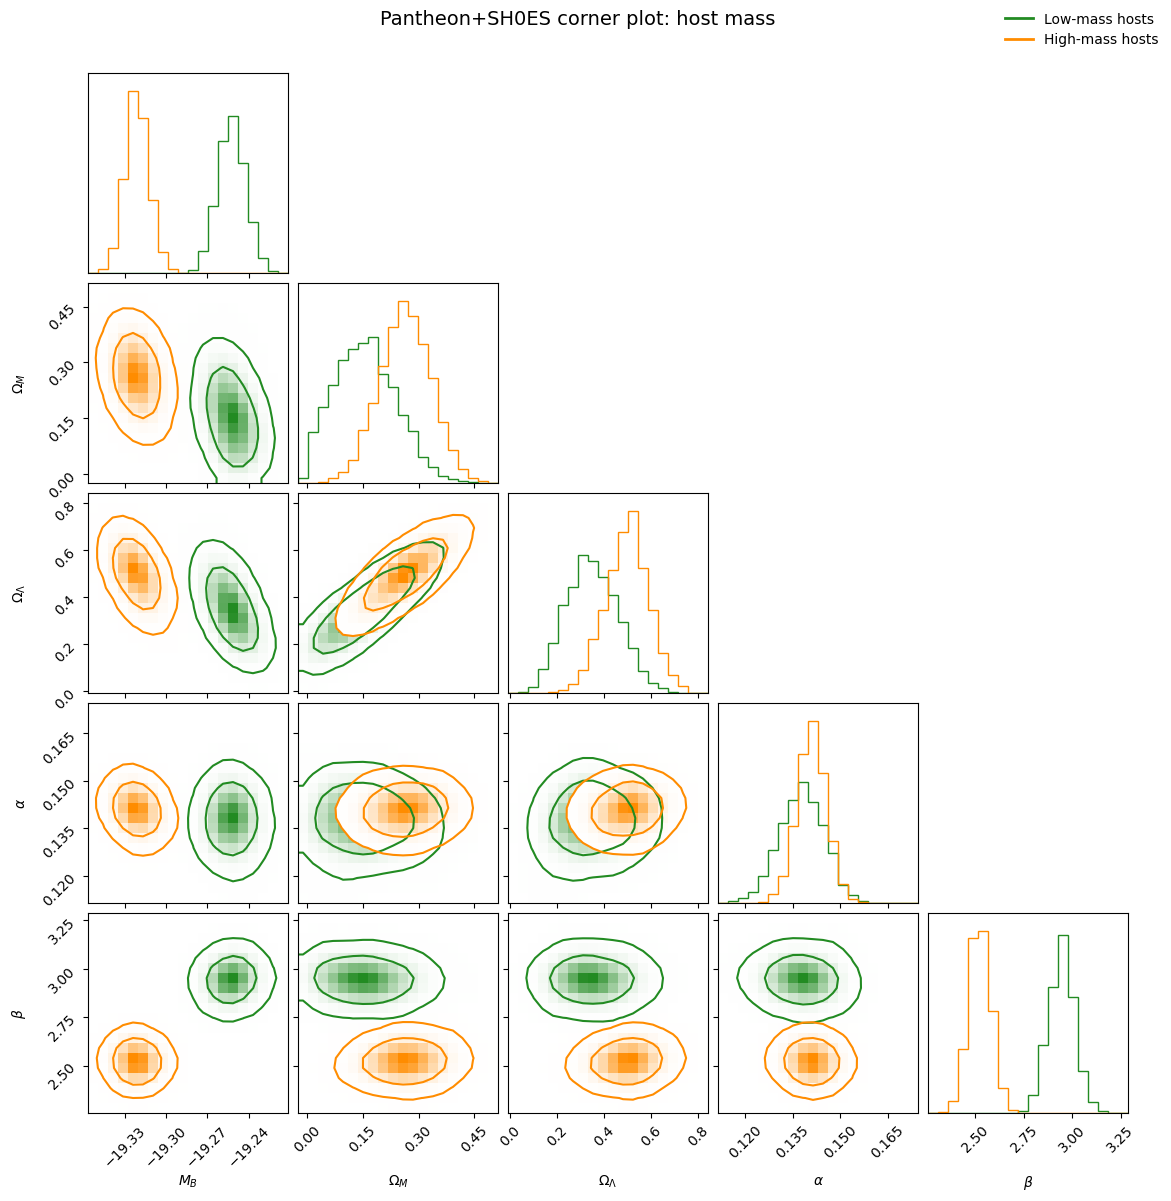

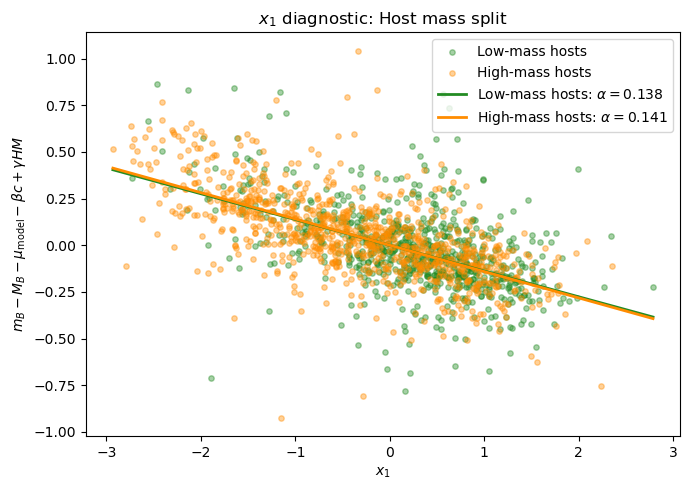

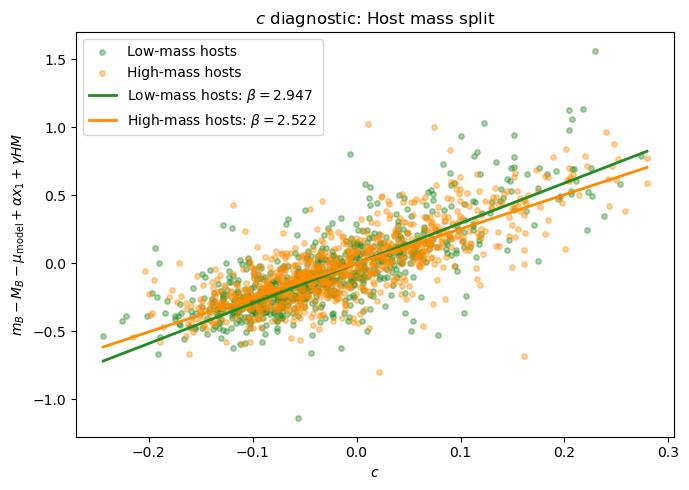

In [19]:
plot_overlaid_corner(
    low_mass_samples_5d,
    high_mass_samples_5d,
    "Low-mass hosts",
    "High-mass hosts",
    "Pantheon+SH0ES corner plot: host mass",
    "forestgreen",
    "darkorange",
    filename=nonclipped_5d_dir / "Pantheon+SH0ES_corner_host_mass_5d.png"
)

plot_mcmc_diagnostics_split(
    low_mass_df_5d,
    low_mass_samples_5d,
    high_mass_df_5d,
    high_mass_samples_5d,
    low_label="Low-mass hosts",
    high_label="High-mass hosts",
    low_color="forestgreen",
    high_color="darkorange",
    title="Host mass split",
    filename_prefix="Pantheon+SH0ES_host_mass",
    clipped=False
)

In [20]:
all_sampler_5d, all_samples_5d = run_mcmc(
    all_data_5d,
    initial_guess_5d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=175
)

all_summary_5d = summarize_samples(
    "All Pantheon+SH0ES supernovae: 5-parameter LambdaCDM",
    all_samples_5d,
    filename=nonclipped_5d_dir / "Pantheon+SH0ES_all_5d.txt"
)

np.save(nonclipped_5d_dir / "Pantheon+SH0ES_all_samples_5d.npy", all_samples_5d)
np.save(nonclipped_5d_dir / "Pantheon+SH0ES_all_chain_5d.npy", all_sampler_5d.get_chain())

100%|██████████████████████████████████████| 3000/3000 [04:53<00:00, 10.21it/s]


All Pantheon+SH0ES supernovae: 5-parameter LambdaCDM
M_B = -19.2917 -0.0065 +0.0066
Omega_M = 0.2080 -0.0524 +0.0558
Omega_Lambda = 0.4286 -0.0730 +0.0773
alpha = 0.1320 -0.0035 +0.0038
beta = 2.6894 -0.0436 +0.0458


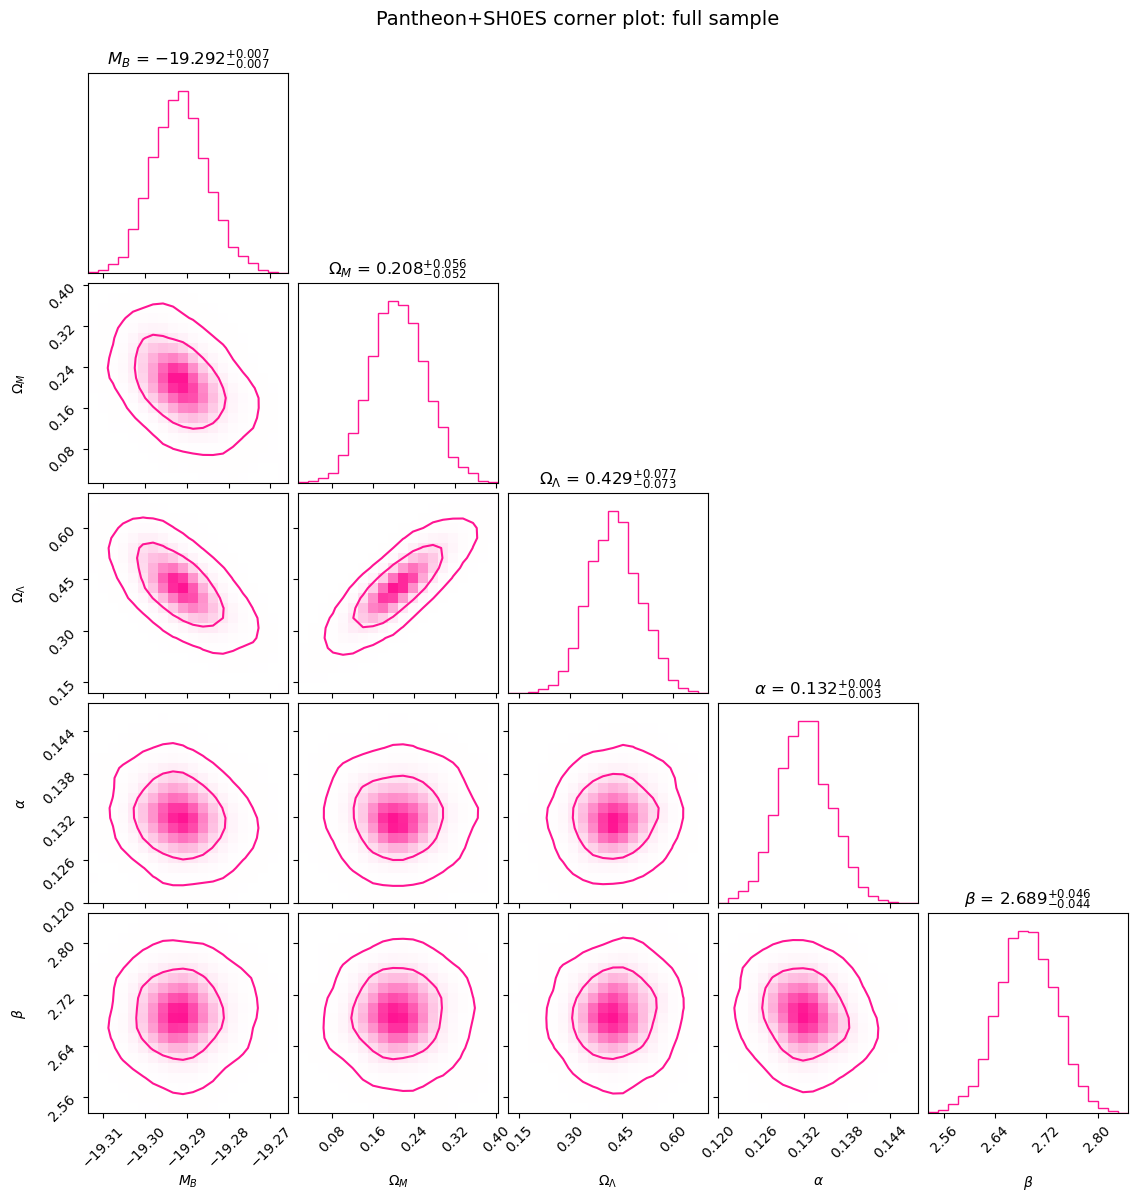

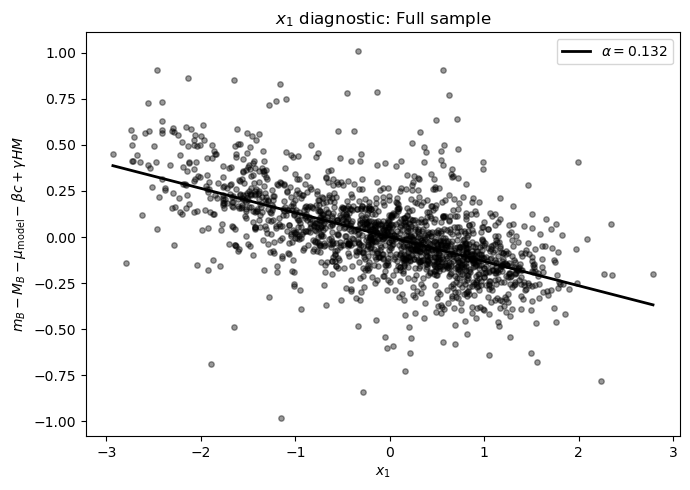

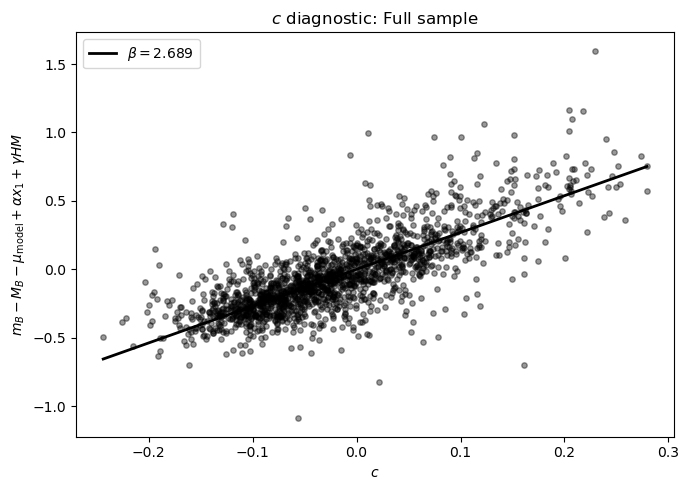

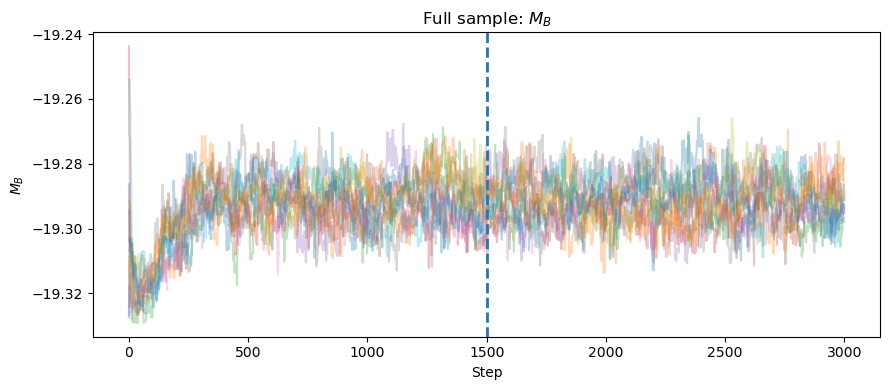

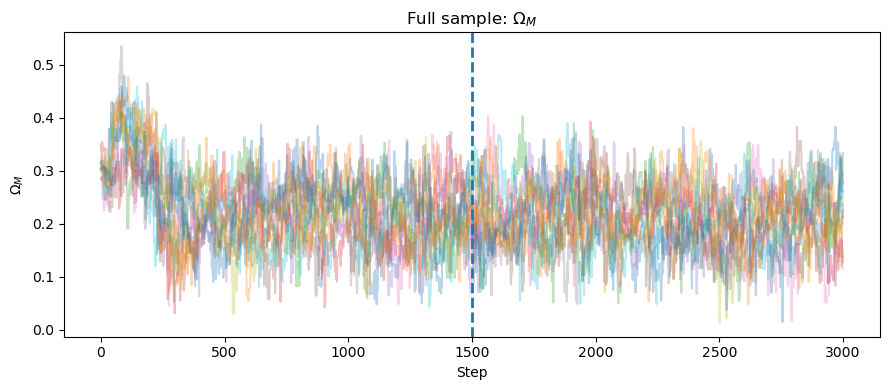

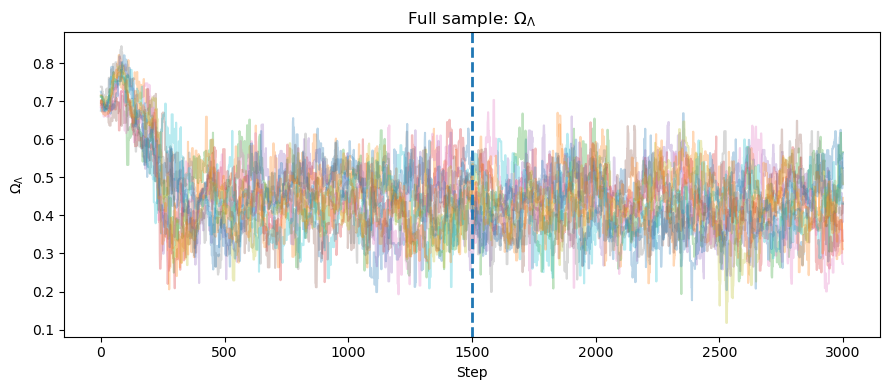

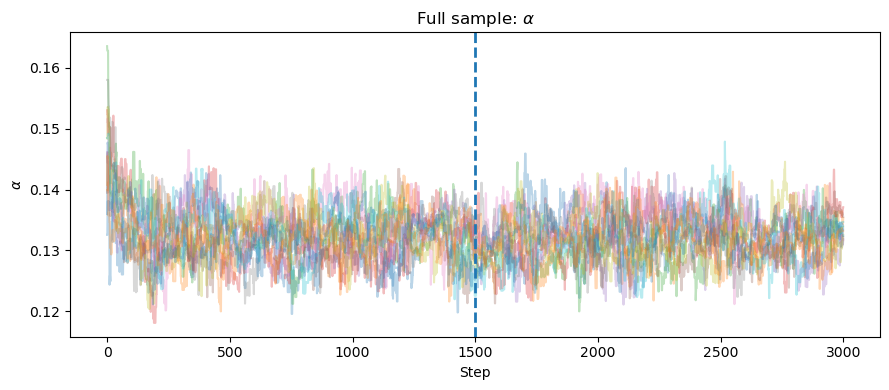

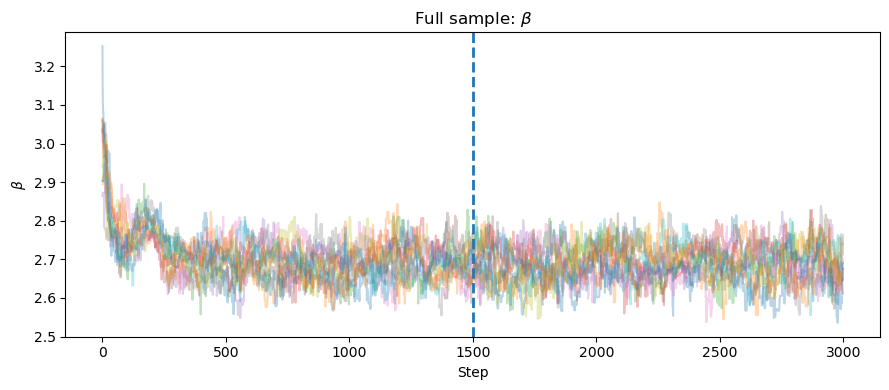

In [21]:
fig = corner.corner(
    all_samples_5d,
    labels=[
        r"$M_B$",
        r"$\Omega_M$",
        r"$\Omega_\Lambda$",
        r"$\alpha$",
        r"$\beta$",
    ],
    levels=(0.683, 0.954),
    color="deeppink",
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    smooth=1.0,
    show_titles=True,
    title_fmt=".3f"
)

fig.suptitle("Pantheon+SH0ES corner plot: full sample", fontsize=14, y=1.02)

fig.savefig(
    nonclipped_5d_dir / "Pantheon+SH0ES_corner_full_sample_5d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plot_mcmc_diagnostics(
    pantheon_sample_5d,
    all_samples_5d,
    title="Full sample",
    filename_prefix="Pantheon+SH0ES_full_sample",
    clipped=False
)

plot_burnin_diagnostics(
    all_sampler_5d,
    burnin=burnin,
    title="Full sample",
    filename_prefix="Pantheon+SH0ES_full_sample",
    clipped=False
)

## Non-Clipped 6D Fits

Fit $M_B$, $\Omega_M$, $\Omega_\Lambda$, $\alpha$, $\beta$, and $\gamma$, with $H_0$ fixed.

In [22]:
all_sampler_6d, all_samples_6d = run_mcmc(
    all_data_6d,
    initial_guess_6d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=175
)

all_summary_6d = summarize_samples(
    "All Pantheon+SH0ES supernovae: 6-parameter LambdaCDM",
    all_samples_6d,
    filename=nonclipped_6d_dir / "Pantheon+SH0ES_all_6d.txt"
)

np.save(nonclipped_6d_dir / "Pantheon+SH0ES_all_samples_6d.npy", all_samples_6d)
np.save(nonclipped_6d_dir / "Pantheon+SH0ES_all_chain_6d.npy", all_sampler_6d.get_chain())

100%|██████████████████████████████████████| 3000/3000 [05:02<00:00,  9.91it/s]


All Pantheon+SH0ES supernovae: 6-parameter LambdaCDM
M_B = -19.2631 -0.0081 +0.0079
Omega_M = 0.2274 -0.0595 +0.0582
Omega_Lambda = 0.4467 -0.0819 +0.0782
alpha = 0.1403 -0.0039 +0.0039
beta = 2.6949 -0.0415 +0.0397
gamma = 0.0541 -0.0074 +0.0070


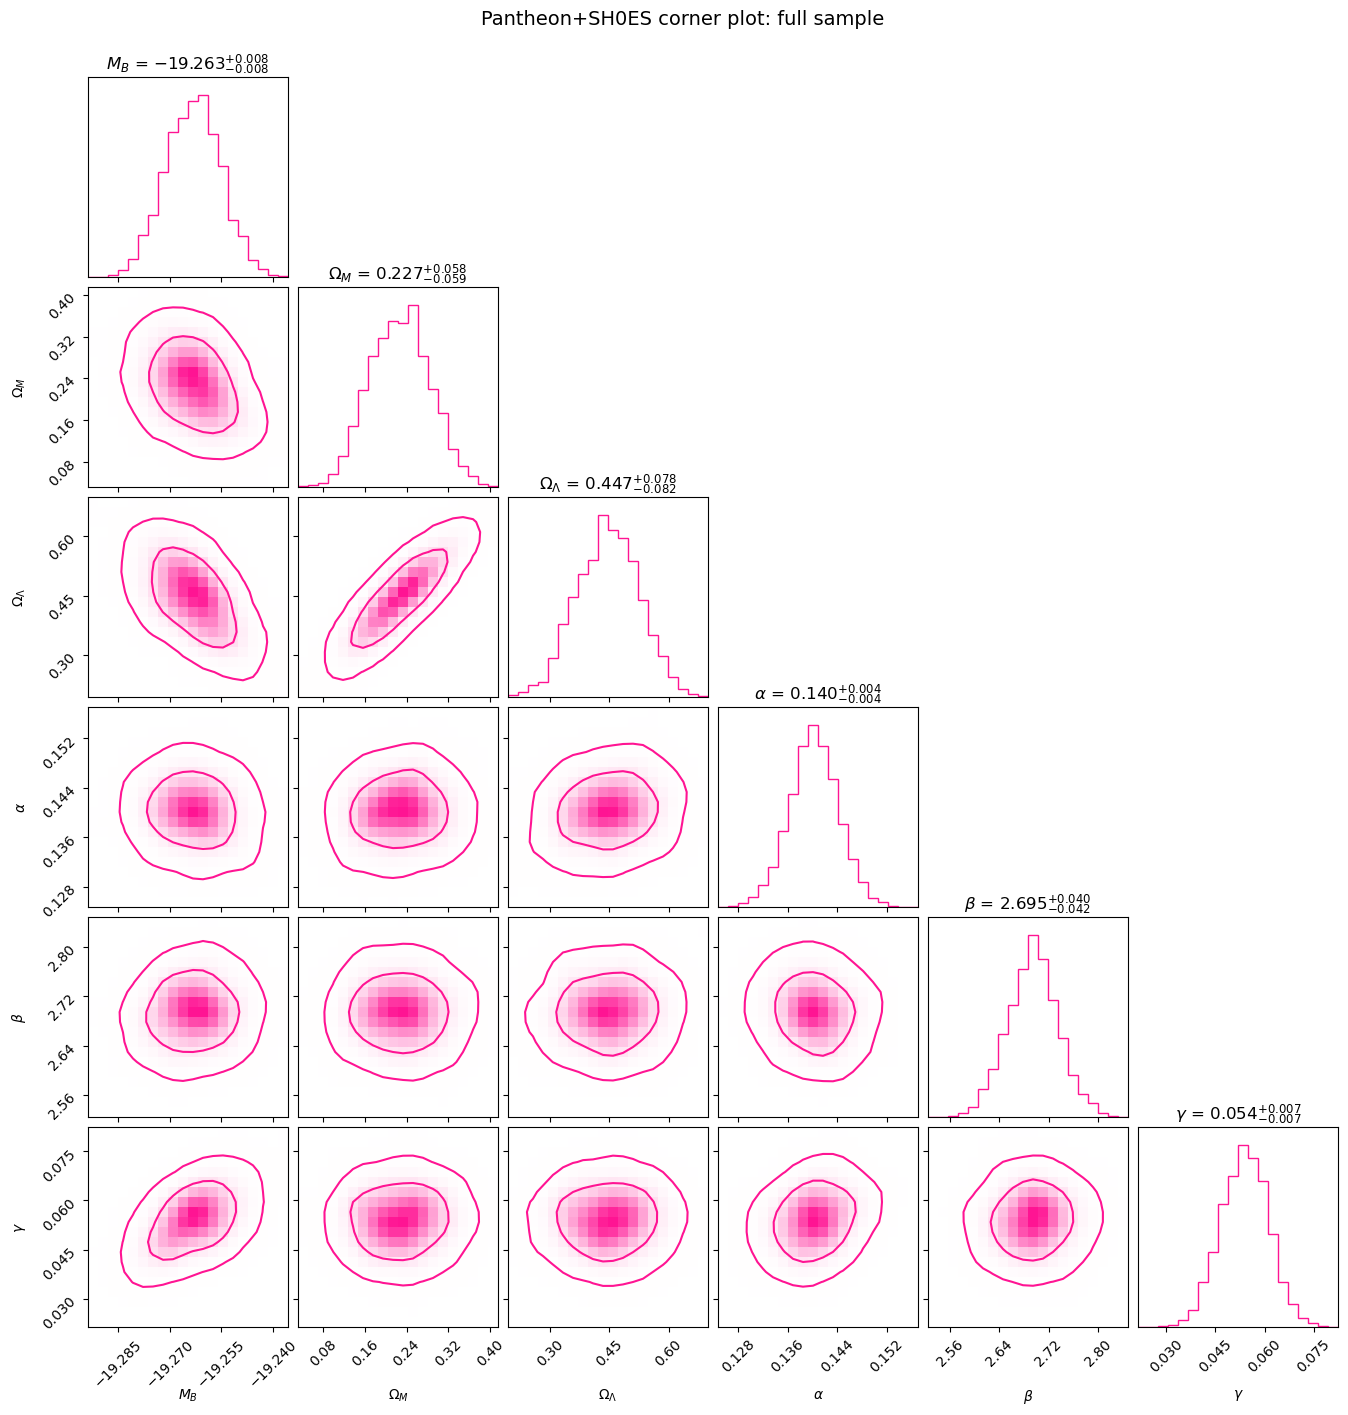

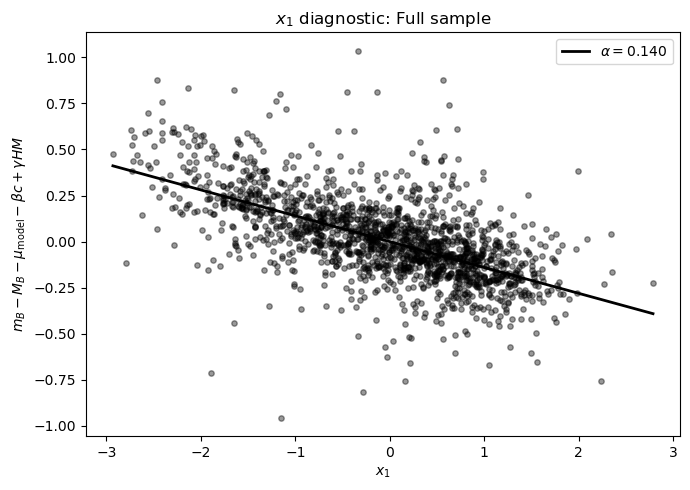

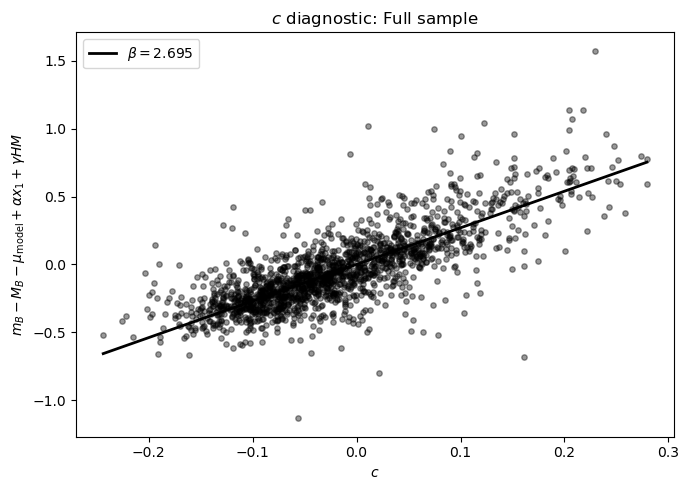

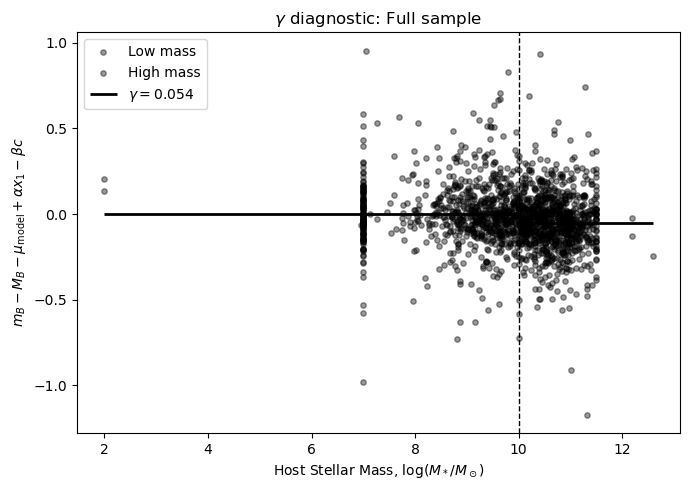

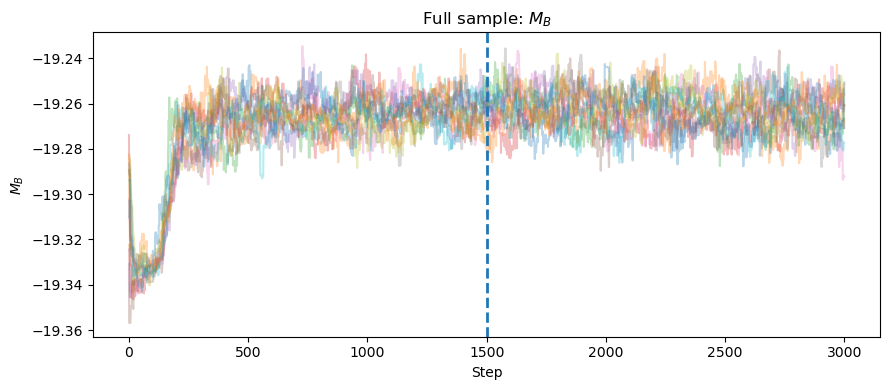

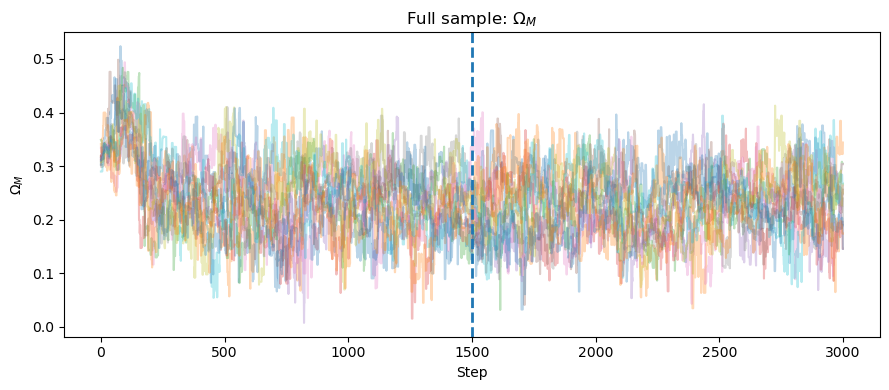

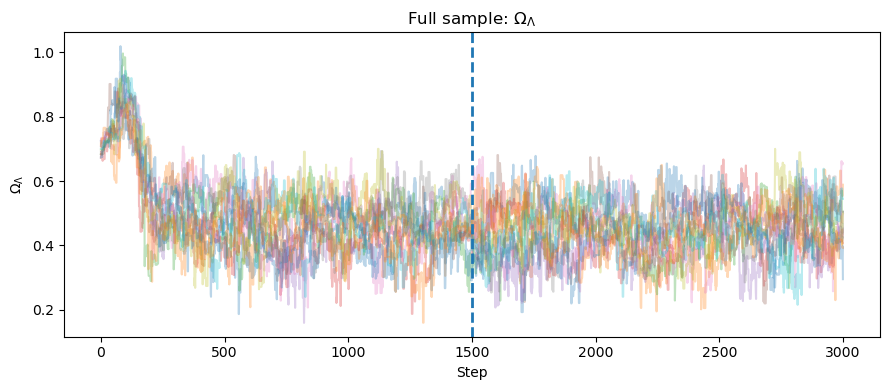

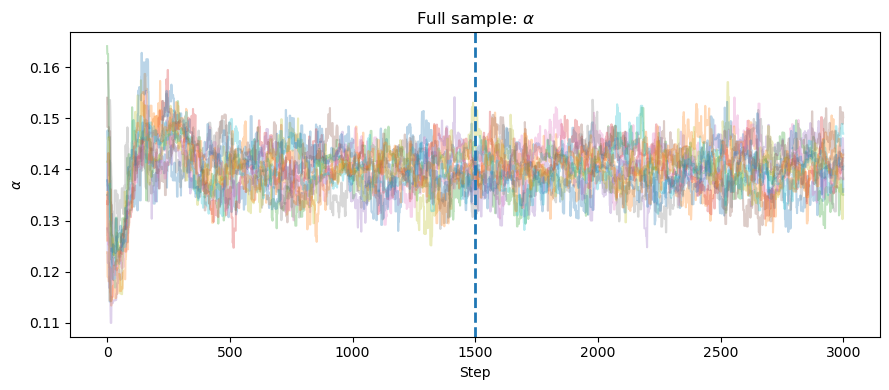

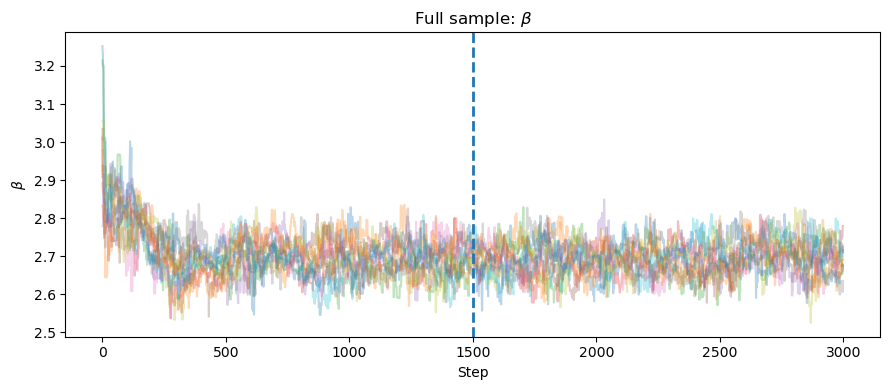

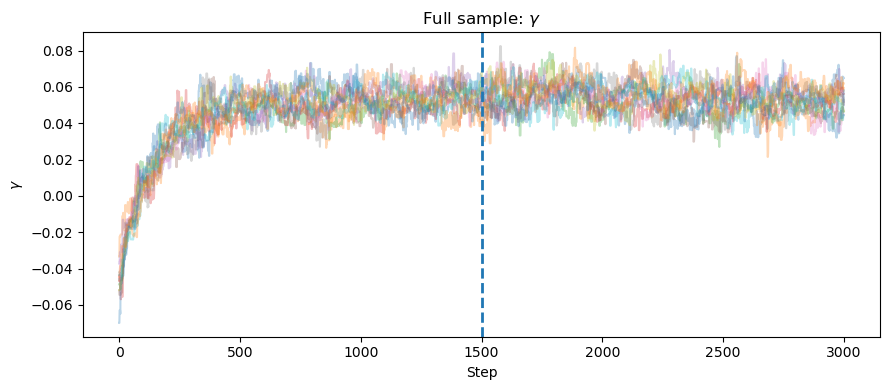

In [23]:
fig = corner.corner(
    all_samples_6d,
    labels=[
        r"$M_B$",
        r"$\Omega_M$",
        r"$\Omega_\Lambda$",
        r"$\alpha$",
        r"$\beta$",
        r"$\gamma$"
    ],
    levels=(0.683, 0.954),
    color="deeppink",
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    smooth=1.0,
    show_titles=True,
    title_fmt=".3f"
)

fig.suptitle("Pantheon+SH0ES corner plot: full sample", fontsize=14, y=1.02)

fig.savefig(
    nonclipped_6d_dir / "Pantheon+SH0ES_corner_full_sample_6d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plot_mcmc_diagnostics(
    pantheon_sample_6d,
    all_samples_6d,
    title="Full sample",
    filename_prefix="Pantheon+SH0ES_full_sample",
    clipped=False
)

plot_burnin_diagnostics(
    all_sampler_6d,
    burnin=burnin,
    title="Full sample",
    filename_prefix="Pantheon+SH0ES_full_sample",
    clipped=False
)

# 2.5-Sigma Clipping

- **5D:** uses the median `all_samples_5d` values of $M_B$, $\Omega_M$, $\Omega_\Lambda$, $\alpha$, $\beta$.
- **6D:** uses the median `all_samples_6d` values of $M_B$, $\Omega_M$, $\Omega_\Lambda$, $\alpha$, $\beta$, and $\gamma$.

In [24]:
# =====================================================
# 5D clipping from the non-clipped 5D fit
# Parameters: M_B, Omega_M, Omega_Lambda, alpha, beta
# H0 is fixed at H_0
# =====================================================

M_B_clip_5d = np.median(all_samples_5d[:, 0])
Omega_M_clip_5d = np.median(all_samples_5d[:, 1])
Omega_Lambda_clip_5d = np.median(all_samples_5d[:, 2])
alpha_clip_5d = np.median(all_samples_5d[:, 3])
beta_clip_5d = np.median(all_samples_5d[:, 4])

cosmology_clip_5d = LambdaCDM(
    H0=H_0,
    Om0=Omega_M_clip_5d,
    Ode0=Omega_Lambda_clip_5d
)

pantheon_sample_clipped_5d = pantheon_sample_5d.copy()
pantheon_sample_clipped_5d["MU_OBS"] = (
    pantheon_sample_clipped_5d["mB"]
    - M_B_clip_5d
    + alpha_clip_5d * pantheon_sample_clipped_5d["x1"]
    - beta_clip_5d * pantheon_sample_clipped_5d["c"]
)

pantheon_sample_clipped_5d["MU_PRED"] = cosmology_clip_5d.distmod(pantheon_sample_clipped_5d["zHD"].to_numpy()).value
pantheon_sample_clipped_5d["RESIDUAL"] = pantheon_sample_clipped_5d["MU_OBS"] - pantheon_sample_clipped_5d["MU_PRED"]

pantheon_sample_clipped_5d["VARIANCE"] = (
    pantheon_sample_clipped_5d["mBERR"]**2
    + alpha_clip_5d**2 * pantheon_sample_clipped_5d["x1ERR"]**2
    + beta_clip_5d**2 * pantheon_sample_clipped_5d["cERR"]**2
    + 2.0 * alpha_clip_5d * pantheon_sample_clipped_5d["COV_mB_x1"]
    - 2.0 * beta_clip_5d * pantheon_sample_clipped_5d["COV_mB_c"]
    - 2.0 * alpha_clip_5d * beta_clip_5d * pantheon_sample_clipped_5d["COV_x1_c"]
    + pantheon_sample_clipped_5d["MUERR_VPEC"]**2
    + pantheon_sample_clipped_5d["LENSDMUERR"]**2
    + sigma_int**2
)

pantheon_sample_clipped_5d["SIGMA_TOTAL"] = np.sqrt(pantheon_sample_clipped_5d["VARIANCE"])
pantheon_sample_clipped_5d["SIGMA_RESIDUAL"] = pantheon_sample_clipped_5d["RESIDUAL"] / pantheon_sample_clipped_5d["SIGMA_TOTAL"]

outliers_5d = pantheon_sample_clipped_5d[np.abs(pantheon_sample_clipped_5d["SIGMA_RESIDUAL"]) > sigma_cut].copy()
pantheon_sample_clipped_5d = pantheon_sample_clipped_5d[np.abs(pantheon_sample_clipped_5d["SIGMA_RESIDUAL"]) <= sigma_cut].copy()


# =====================================================
# 6D clipping from the non-clipped 6D fit
# Parameters: M_B, Omega_M, Omega_Lambda, alpha, beta, gamma
# H0 is fixed at H_0
# =====================================================

M_B_clip_6d = np.median(all_samples_6d[:, 0])
Omega_M_clip_6d = np.median(all_samples_6d[:, 1])
Omega_Lambda_clip_6d = np.median(all_samples_6d[:, 2])
alpha_clip_6d = np.median(all_samples_6d[:, 3])
beta_clip_6d = np.median(all_samples_6d[:, 4])
gamma_clip_6d = np.median(all_samples_6d[:, 5])

cosmology_clip_6d = LambdaCDM(
    H0=H_0,
    Om0=Omega_M_clip_6d,
    Ode0=Omega_Lambda_clip_6d
)

pantheon_sample_clipped_6d = pantheon_sample_6d.copy()
HM_clip_6d = (pantheon_sample_clipped_6d["HOST_LOGMASS"] >= mass_cut).astype(float)

pantheon_sample_clipped_6d["MU_OBS"] = (
    pantheon_sample_clipped_6d["mB"]
    - M_B_clip_6d
    + alpha_clip_6d * pantheon_sample_clipped_6d["x1"]
    - beta_clip_6d * pantheon_sample_clipped_6d["c"]
    + gamma_clip_6d * HM_clip_6d
)

pantheon_sample_clipped_6d["MU_PRED"] = cosmology_clip_6d.distmod(pantheon_sample_clipped_6d["zHD"].to_numpy()).value
pantheon_sample_clipped_6d["RESIDUAL"] = pantheon_sample_clipped_6d["MU_OBS"] - pantheon_sample_clipped_6d["MU_PRED"]

pantheon_sample_clipped_6d["VARIANCE"] = (
    pantheon_sample_clipped_6d["mBERR"]**2
    + alpha_clip_6d**2 * pantheon_sample_clipped_6d["x1ERR"]**2
    + beta_clip_6d**2 * pantheon_sample_clipped_6d["cERR"]**2
    + 2.0 * alpha_clip_6d * pantheon_sample_clipped_6d["COV_mB_x1"]
    - 2.0 * beta_clip_6d * pantheon_sample_clipped_6d["COV_mB_c"]
    - 2.0 * alpha_clip_6d * beta_clip_6d * pantheon_sample_clipped_6d["COV_x1_c"]
    + pantheon_sample_clipped_6d["MUERR_VPEC"]**2
    + pantheon_sample_clipped_6d["LENSDMUERR"]**2
    + sigma_int**2
)

pantheon_sample_clipped_6d["SIGMA_TOTAL"] = np.sqrt(pantheon_sample_clipped_6d["VARIANCE"])
pantheon_sample_clipped_6d["SIGMA_RESIDUAL"] = pantheon_sample_clipped_6d["RESIDUAL"] / pantheon_sample_clipped_6d["SIGMA_TOTAL"]

outliers_6d = pantheon_sample_clipped_6d[np.abs(pantheon_sample_clipped_6d["SIGMA_RESIDUAL"]) > sigma_cut].copy()
pantheon_sample_clipped_6d = pantheon_sample_clipped_6d[np.abs(pantheon_sample_clipped_6d["SIGMA_RESIDUAL"]) <= sigma_cut].copy()

print(f"5D: {len(pantheon_sample_5d)} -> {len(pantheon_sample_clipped_5d)} ({len(outliers_5d)} removed)")
print(f"6D: {len(pantheon_sample_6d)} -> {len(pantheon_sample_clipped_6d)} ({len(outliers_6d)} removed)")

5D: 1689 -> 1633 (56 removed)
6D: 1689 -> 1639 (50 removed)


In [25]:
# =====================================================
# 5D clipped splits and tuples
# =====================================================

clipped_low_mass_df_5d = pantheon_sample_clipped_5d[pantheon_sample_clipped_5d["HOST_LOGMASS"] < mass_cut].copy()
clipped_high_mass_df_5d = pantheon_sample_clipped_5d[pantheon_sample_clipped_5d["HOST_LOGMASS"] >= mass_cut].copy()

clipped_all_data_5d = make_data_tuple(pantheon_sample_clipped_5d, nparam=5)
clipped_low_mass_data_5d = make_data_tuple(clipped_low_mass_df_5d, nparam=5)
clipped_high_mass_data_5d = make_data_tuple(clipped_high_mass_df_5d, nparam=5)


# =====================================================
# 6D clipped splits and tuples
# =====================================================

clipped_all_data_6d = make_data_tuple(pantheon_sample_clipped_6d, nparam=6)

## Clipped 5D Fits

In [26]:
clipped_low_mass_sampler_5d, clipped_low_mass_samples_5d = run_mcmc(
    clipped_low_mass_data_5d,
    initial_guess_5d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=151
)

clipped_low_mass_summary_5d = summarize_samples(
    "Low-mass hosts: clipped 5-parameter LambdaCDM",
    clipped_low_mass_samples_5d,
    filename=clipped_5d_dir / "Pantheon+SH0ES_low_mass_5d_clipped.txt"
)

clipped_high_mass_sampler_5d, clipped_high_mass_samples_5d = run_mcmc(
    clipped_high_mass_data_5d,
    initial_guess_5d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=152
)

clipped_high_mass_summary_5d = summarize_samples(
    "High-mass hosts: clipped 5-parameter LambdaCDM",
    clipped_high_mass_samples_5d,
    filename=clipped_5d_dir / "Pantheon+SH0ES_high_mass_5d_clipped.txt"
)

np.save(clipped_5d_dir / "Pantheon+SH0ES_clipped_low_mass_samples_5d.npy", clipped_low_mass_samples_5d)
np.save(clipped_5d_dir / "Pantheon+SH0ES_clipped_high_mass_samples_5d.npy", clipped_high_mass_samples_5d)

100%|██████████████████████████████████████| 3000/3000 [03:16<00:00, 15.25it/s]



Low-mass hosts: clipped 5-parameter LambdaCDM
M_B = -19.2762 -0.0095 +0.0102
Omega_M = 0.2078 -0.0922 +0.0854
Omega_Lambda = 0.4237 -0.1190 +0.1196
alpha = 0.1355 -0.0069 +0.0068
beta = 2.6323 -0.0670 +0.0684


100%|██████████████████████████████████████| 3000/3000 [03:42<00:00, 13.47it/s]


High-mass hosts: clipped 5-parameter LambdaCDM
M_B = -19.3144 -0.0087 +0.0091
Omega_M = 0.2492 -0.0709 +0.0671
Omega_Lambda = 0.4640 -0.0973 +0.0872
alpha = 0.1412 -0.0048 +0.0046
beta = 2.5071 -0.0510 +0.0498


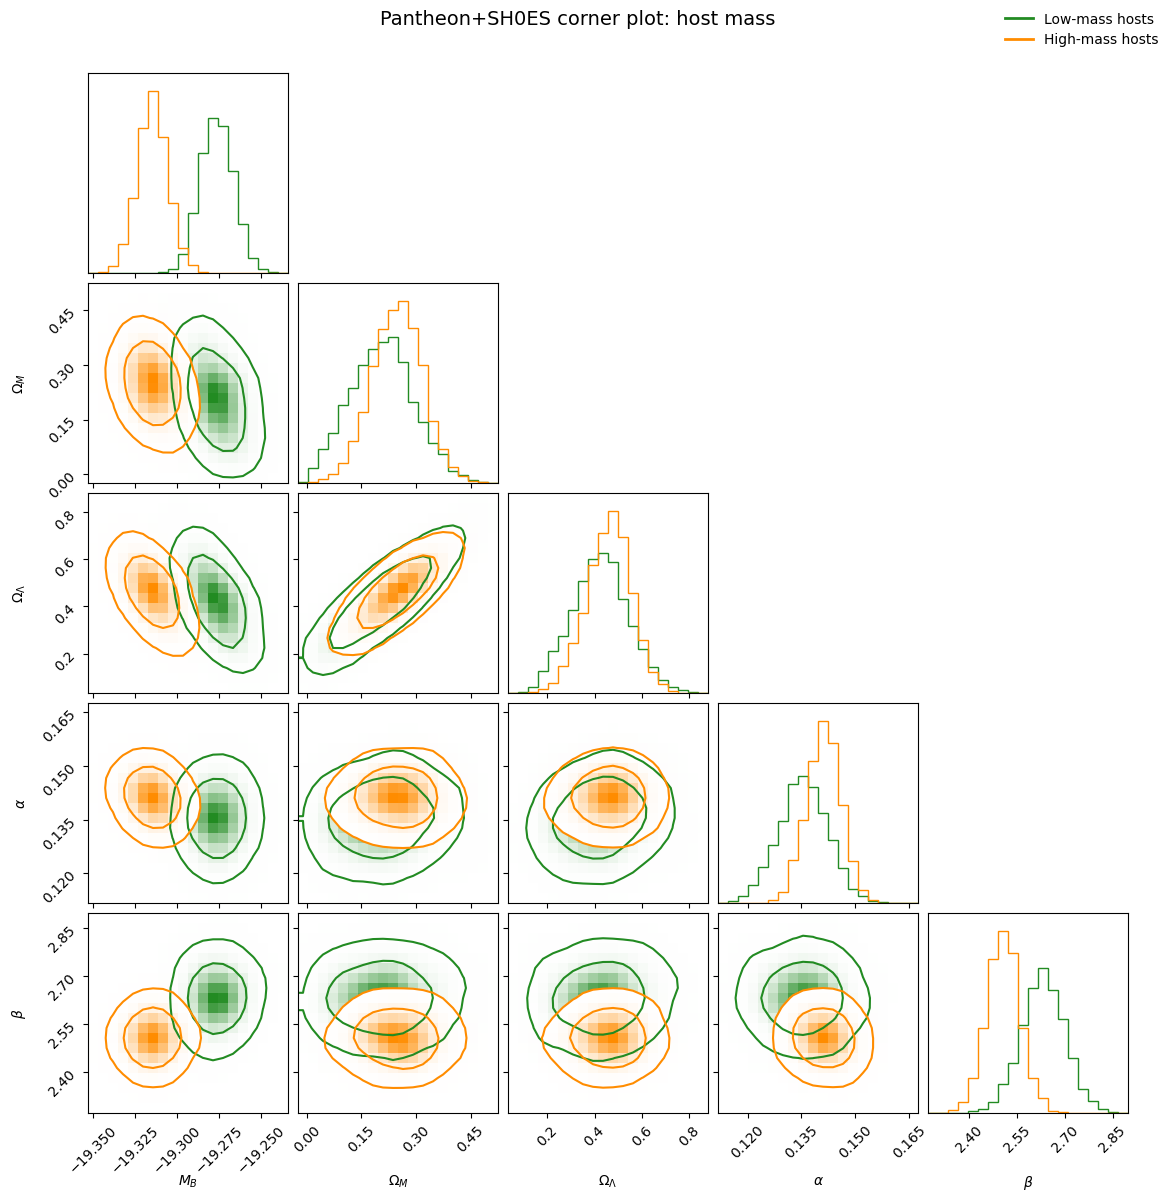

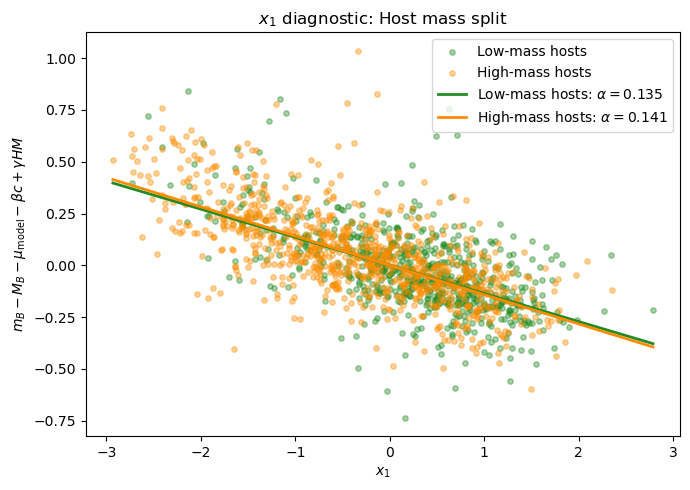

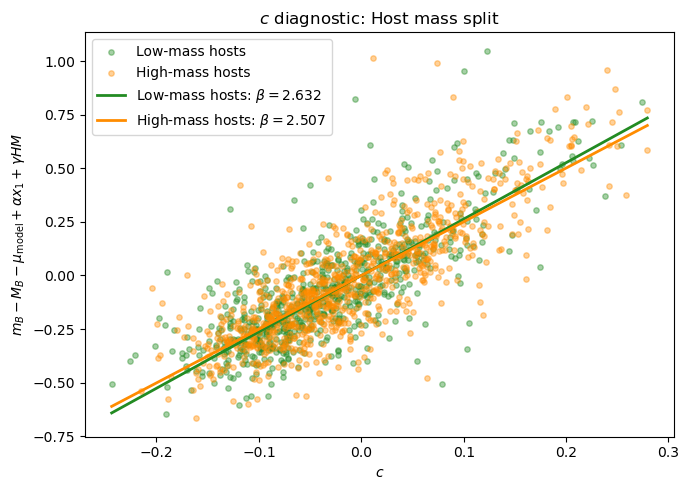

In [27]:
plot_overlaid_corner(
    clipped_low_mass_samples_5d,
    clipped_high_mass_samples_5d,
    "Low-mass hosts",
    "High-mass hosts",
    "Pantheon+SH0ES corner plot: host mass",
    "forestgreen",
    "darkorange",
    filename=clipped_5d_dir / "Pantheon+SH0ES_clipped_corner_host_mass_5d.png"
)

plot_mcmc_diagnostics_split(
    clipped_low_mass_df_5d,
    clipped_low_mass_samples_5d,
    clipped_high_mass_df_5d,
    clipped_high_mass_samples_5d,
    low_label="Low-mass hosts",
    high_label="High-mass hosts",
    low_color="forestgreen",
    high_color="darkorange",
    title="Host mass split",
    filename_prefix="Pantheon+SH0ES_host_mass",
    clipped=True
)

In [28]:
clipped_all_sampler_5d, clipped_all_samples_5d = run_mcmc(
    clipped_all_data_5d,
    initial_guess_5d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=156
)

clipped_all_summary_5d = summarize_samples(
    "All Pantheon+SH0ES supernovae: clipped 5-parameter LambdaCDM",
    clipped_all_samples_5d,
    filename=clipped_5d_dir / "Pantheon+SH0ES_clipped_all_5d.txt"
)

np.save(clipped_5d_dir / "Pantheon+SH0ES_clipped_all_samples_5d.npy", clipped_all_samples_5d)
np.save(clipped_5d_dir / "Pantheon+SH0ES_clipped_all_chain_5d.npy", clipped_all_sampler_5d.get_chain())

100%|██████████████████████████████████████| 3000/3000 [05:04<00:00,  9.86it/s]


All Pantheon+SH0ES supernovae: clipped 5-parameter LambdaCDM
M_B = -19.2973 -0.0070 +0.0073
Omega_M = 0.2233 -0.0533 +0.0540
Omega_Lambda = 0.4441 -0.0769 +0.0733
alpha = 0.1341 -0.0038 +0.0038
beta = 2.5494 -0.0441 +0.0394


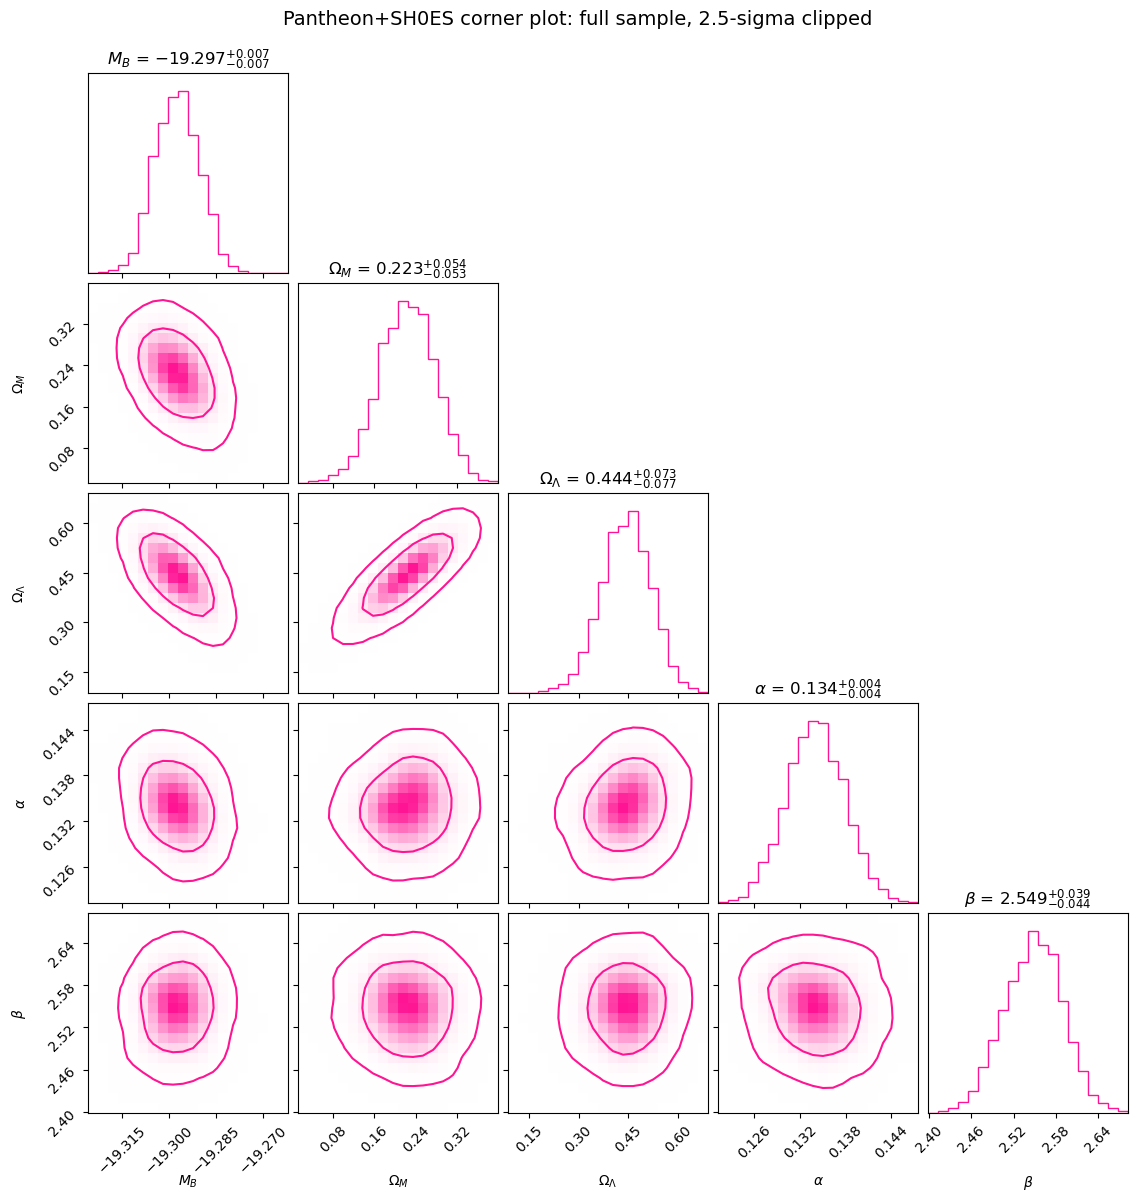

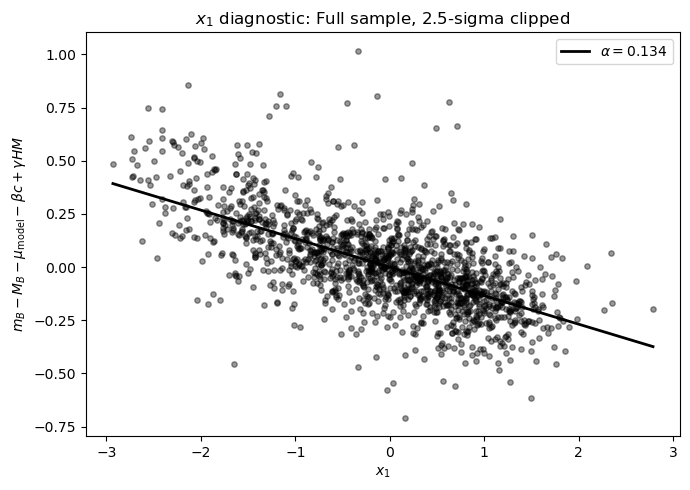

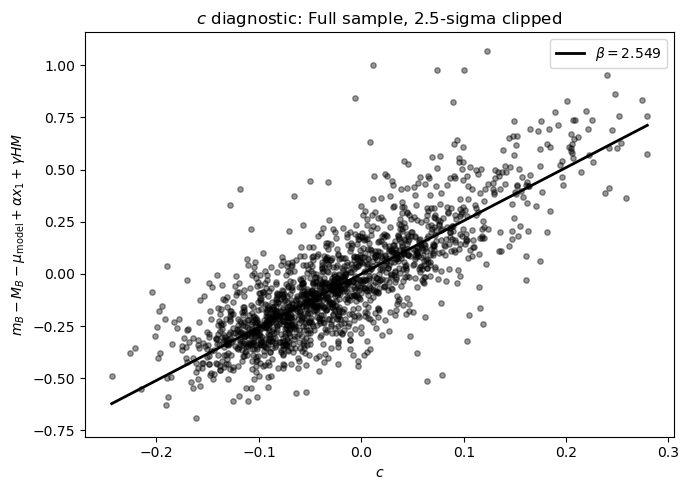

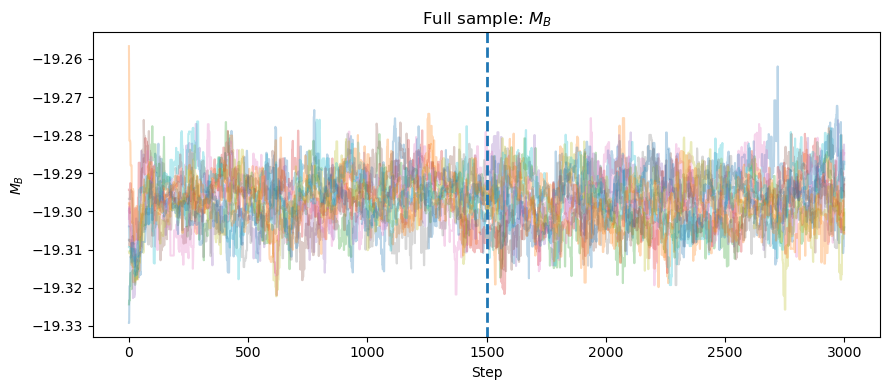

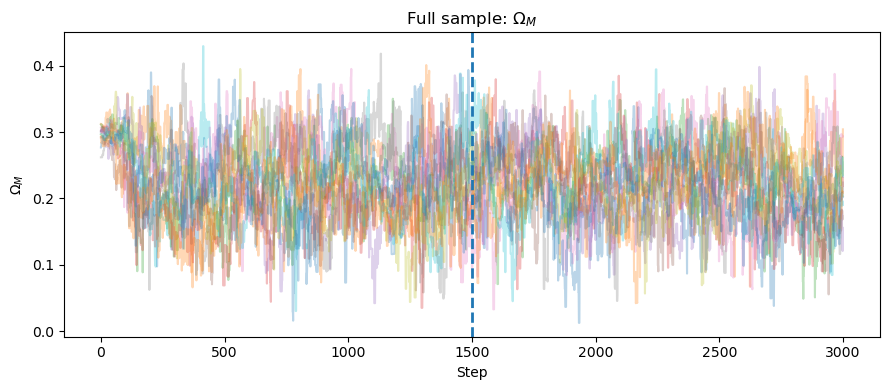

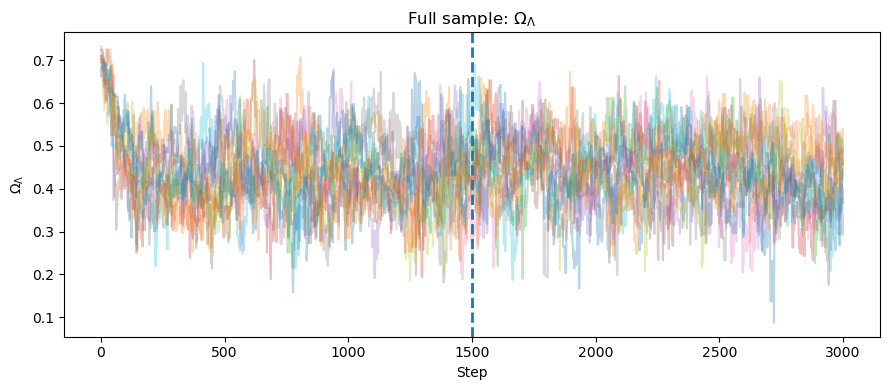

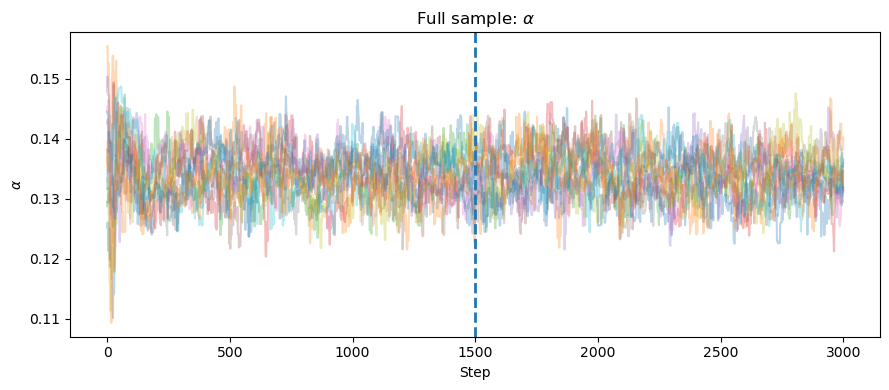

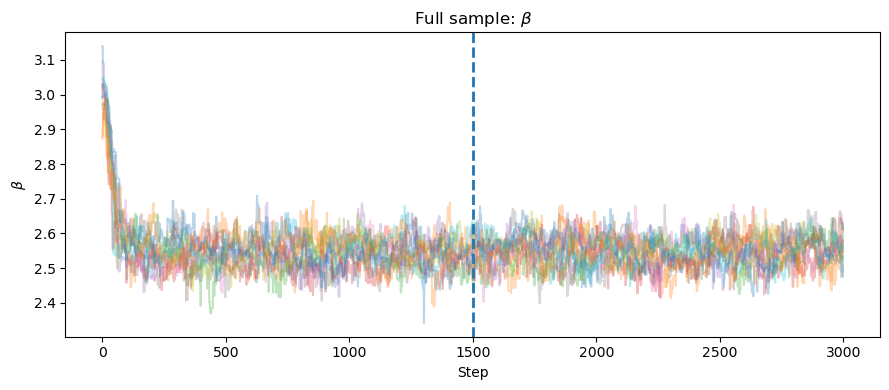

In [29]:
fig = corner.corner(
    clipped_all_samples_5d,
    labels=[
        r"$M_B$",
        r"$\Omega_M$",
        r"$\Omega_\Lambda$",
        r"$\alpha$",
        r"$\beta$",
    ],
    levels=(0.683, 0.954),
    color="deeppink",
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    smooth=1.0,
    show_titles=True,
    title_fmt=".3f"
)

fig.suptitle("Pantheon+SH0ES corner plot: full sample, 2.5-sigma clipped", fontsize=14, y=1.02)

fig.savefig(
    clipped_5d_dir / "Pantheon+SH0ES_clipped_corner_full_sample_5d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plot_mcmc_diagnostics(
    pantheon_sample_clipped_5d,
    clipped_all_samples_5d,
    title="Full sample, 2.5-sigma clipped",
    filename_prefix="Pantheon+SH0ES_full_sample",
    clipped=True
)

plot_burnin_diagnostics(
    clipped_all_sampler_5d,
    burnin=burnin,
    title="Full sample",
    filename_prefix="Pantheon+SH0ES_full_sample",
    clipped=True
)

## Clipped 6D Fits

In [30]:
clipped_all_sampler_6d, clipped_all_samples_6d = run_mcmc(
    clipped_all_data_6d,
    initial_guess_6d,
    nwalkers=nwalkers,
    nsteps=nsteps,
    burnin=burnin,
    thin=thin,
    random_seed=175
)

clipped_all_summary_6d = summarize_samples(
    "All Pantheon+SH0ES supernovae: clipped 6-parameter LambdaCDM",
    clipped_all_samples_6d,
    filename=clipped_6d_dir / "Pantheon+SH0ES_clipped_all_6d.txt"
)

np.save(clipped_6d_dir / "Pantheon+SH0ES_clipped_all_samples_6d.npy", clipped_all_samples_6d)
np.save(clipped_6d_dir / "Pantheon+SH0ES_clipped_all_chain_6d.npy", clipped_all_sampler_6d.get_chain())

100%|██████████████████████████████████████| 3000/3000 [05:07<00:00,  9.77it/s]


All Pantheon+SH0ES supernovae: clipped 6-parameter LambdaCDM
M_B = -19.2694 -0.0083 +0.0077
Omega_M = 0.2334 -0.0528 +0.0538
Omega_Lambda = 0.4348 -0.0714 +0.0671
alpha = 0.1399 -0.0038 +0.0041
beta = 2.5746 -0.0425 +0.0442
gamma = 0.0436 -0.0076 +0.0076


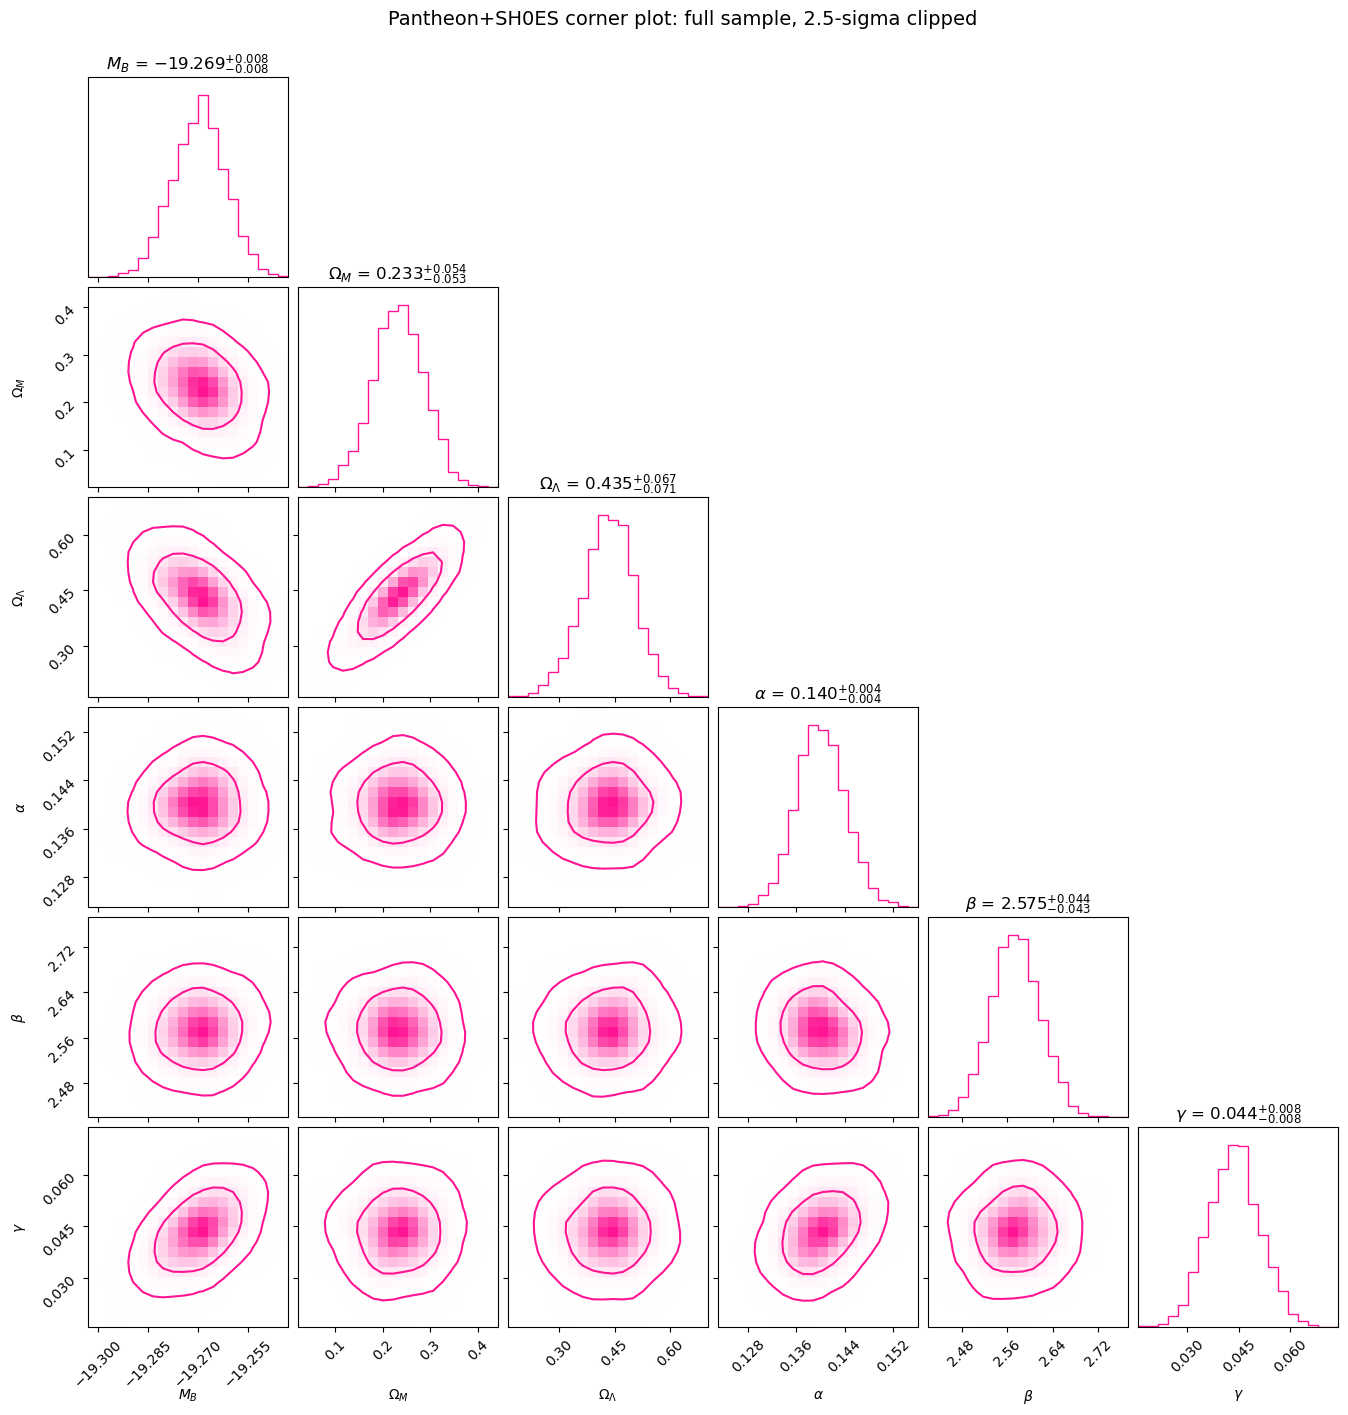

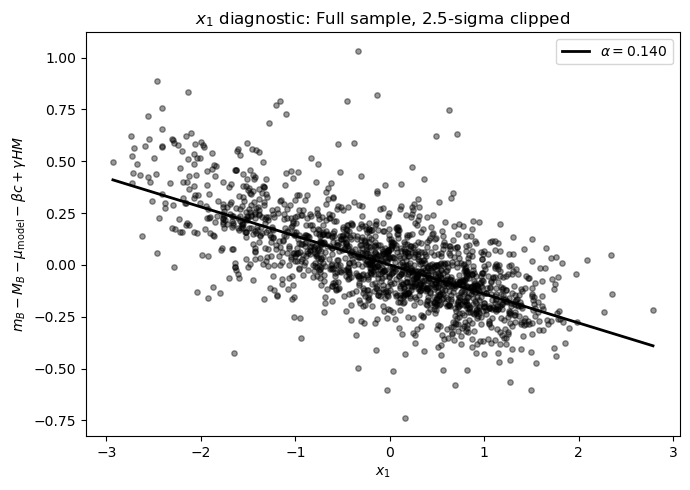

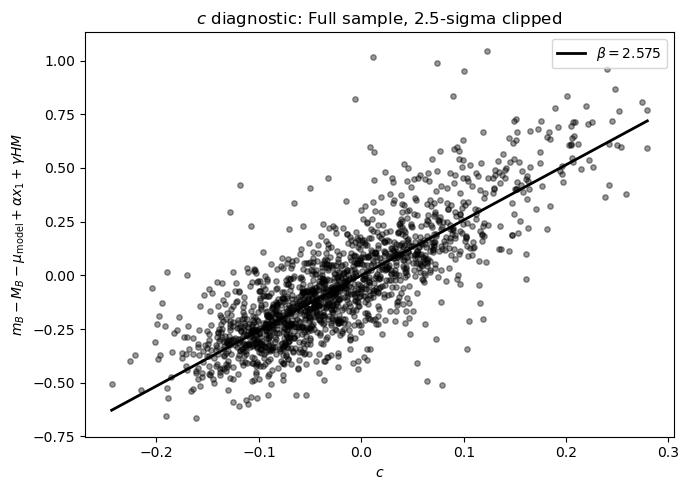

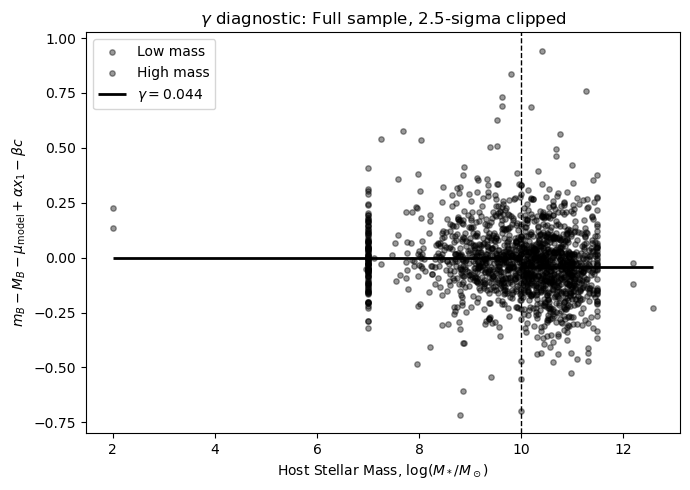

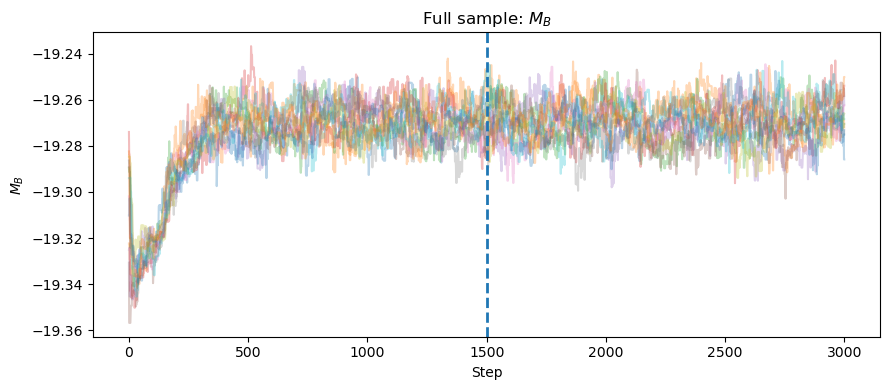

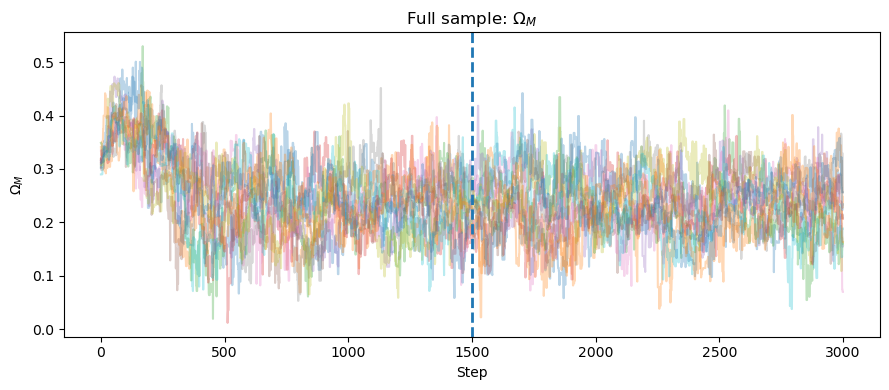

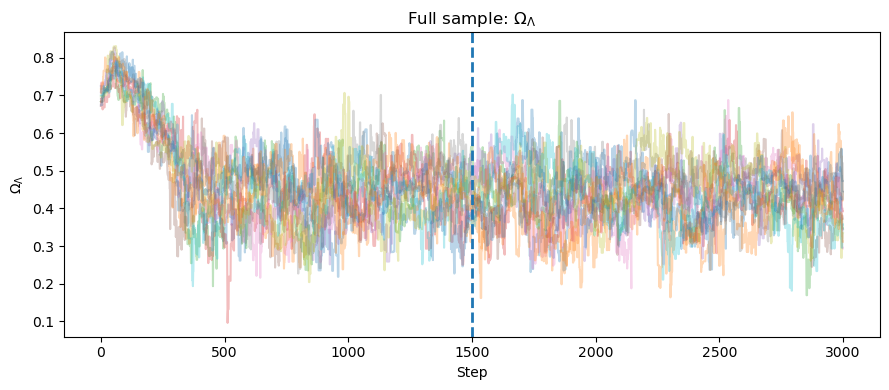

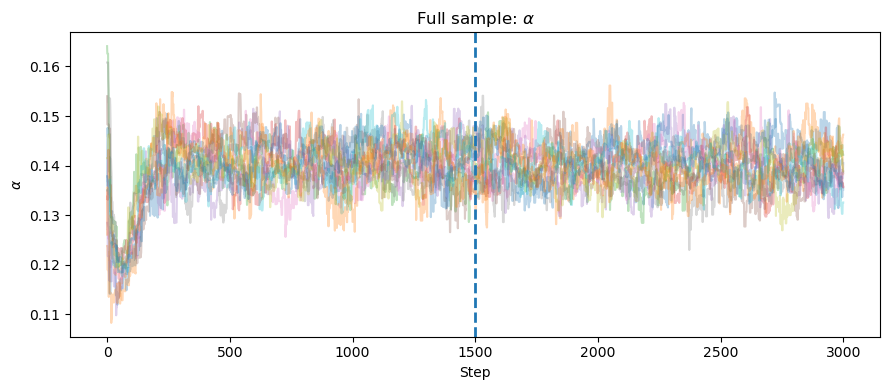

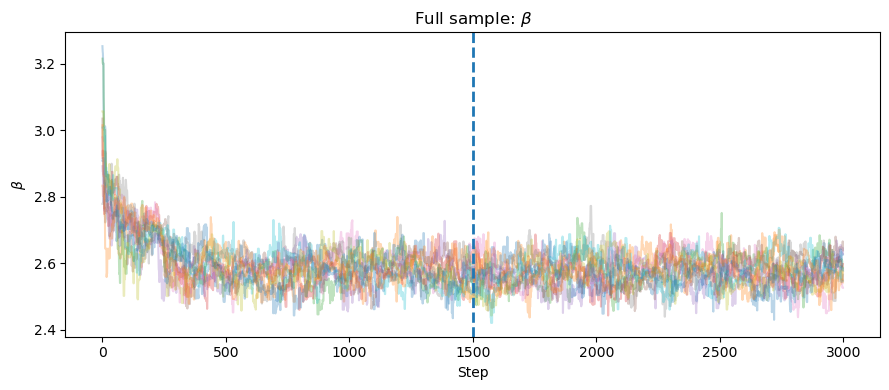

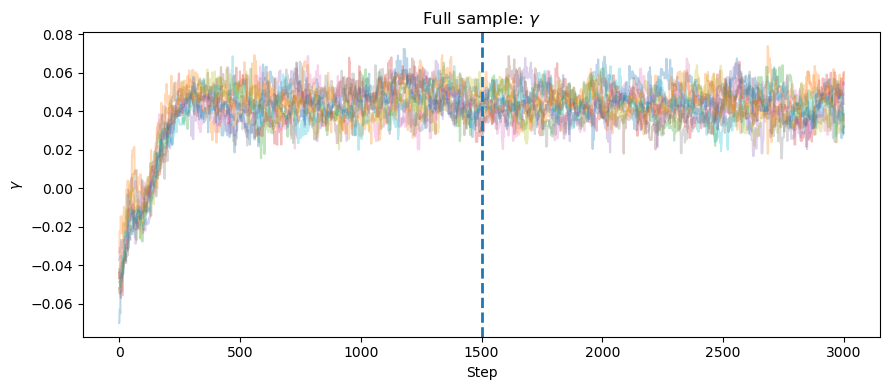

In [31]:
fig = corner.corner(
    clipped_all_samples_6d,
    labels=[
        r"$M_B$",
        r"$\Omega_M$",
        r"$\Omega_\Lambda$",
        r"$\alpha$",
        r"$\beta$",
        r"$\gamma$"
    ],
    levels=(0.683, 0.954),
    color="deeppink",
    plot_datapoints=False,
    plot_density=True,
    fill_contours=False,
    smooth=1.0,
    show_titles=True,
    title_fmt=".3f"
)

fig.suptitle("Pantheon+SH0ES corner plot: full sample, 2.5-sigma clipped", fontsize=14, y=1.02)

fig.savefig(
    clipped_6d_dir / "Pantheon+SH0ES_clipped_corner_full_sample_6d.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plot_mcmc_diagnostics(
    pantheon_sample_clipped_6d,
    clipped_all_samples_6d,
    title="Full sample, 2.5-sigma clipped",
    filename_prefix="Pantheon+SH0ES_full_sample",
    clipped=True
)

plot_burnin_diagnostics(
    clipped_all_sampler_6d,
    burnin=burnin,
    title="Full sample",
    filename_prefix="Pantheon+SH0ES_full_sample",
    clipped=True
)

# Final Hubble Diagrams

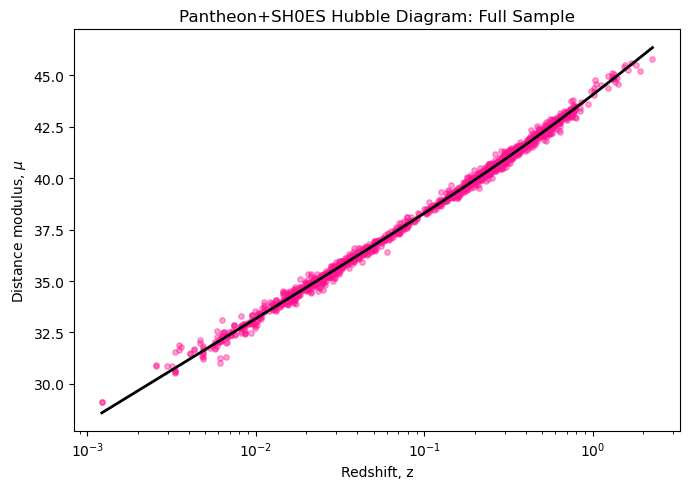

In [32]:
M_B = np.median(all_samples_6d[:, 0])
Omega_M = np.median(all_samples_6d[:, 1])
Omega_Lambda = np.median(all_samples_6d[:, 2])
alpha = np.median(all_samples_6d[:, 3])
beta = np.median(all_samples_6d[:, 4])
gamma = np.median(all_samples_6d[:, 5])

data = pantheon_sample_6d[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

data["MU"] = data["mB"] - M_B + alpha*data["x1"] - beta*data["c"] + gamma*HM

cosmology = LambdaCDM(H0=H_0, Om0=Omega_M, Ode0=Omega_Lambda)

z_plot = np.linspace(data["zHD"].min(), data["zHD"].max(), 500)
mu_plot = cosmology.distmod(z_plot).value

plt.figure(figsize=(7, 5))

plt.scatter(
    data["zHD"],
    data["MU"],
    s=15,
    alpha=0.4,
    color="deeppink"
)

plt.plot(
    z_plot,
    mu_plot,
    color="black",
    linewidth=2
)

plt.xscale("log")
plt.xlabel("Redshift, z")
plt.ylabel(r"Distance modulus, $\mu$")
plt.title("Pantheon+SH0ES Hubble Diagram: Full Sample")
plt.tight_layout()
plt.savefig(hubble_dir / "Pantheon+SH0ES_hubble_full_sample.png", dpi=300, bbox_inches="tight")
plt.show()

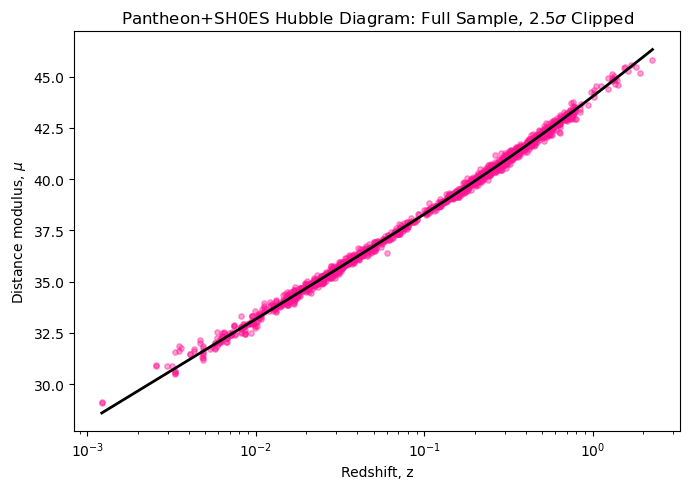

In [33]:
# 2.5-sigma clipped 6D Hubble diagram

M_B = np.median(clipped_all_samples_6d[:, 0])
Omega_M = np.median(clipped_all_samples_6d[:, 1])
Omega_Lambda = np.median(clipped_all_samples_6d[:, 2])
alpha = np.median(clipped_all_samples_6d[:, 3])
beta = np.median(clipped_all_samples_6d[:, 4])
gamma = np.median(clipped_all_samples_6d[:, 5])

data = pantheon_sample_clipped_6d[
    ["zHD", "mB", "x1", "c", "HOST_LOGMASS"]
].dropna().copy()

HM = (data["HOST_LOGMASS"] >= mass_cut).astype(float)

data["MU"] = data["mB"] - M_B + alpha*data["x1"] - beta*data["c"] + gamma*HM

cosmology = LambdaCDM(
    H0=H_0,
    Om0=Omega_M,
    Ode0=Omega_Lambda
)

z_plot = np.linspace(
    data["zHD"].min(),
    data["zHD"].max(),
    500
)

mu_plot = cosmology.distmod(z_plot).value

plt.figure(figsize=(7, 5))

plt.scatter(
    data["zHD"],
    data["MU"],
    s=15,
    alpha=0.4,
    color="deeppink"
)

plt.plot(
    z_plot,
    mu_plot,
    color="black",
    linewidth=2
)

plt.xscale("log")
plt.xlabel("Redshift, z")
plt.ylabel(r"Distance modulus, $\mu$")
plt.title(r"Pantheon+SH0ES Hubble Diagram: Full Sample, $2.5\sigma$ Clipped")

plt.tight_layout()

plt.savefig(
    hubble_dir / "Pantheon+SH0ES_hubble_full_sample_6d_2p5sigma_clipped.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
def plot_hubble_split(
    sample1,
    sample2,
    samples1,
    samples2,
    label1,
    label2,
    color1,
    color2,
    title,
    filename
):
    M_B_1 = np.median(samples1[:, 0])
    Omega_M_1 = np.median(samples1[:, 1])
    Omega_Lambda_1 = np.median(samples1[:, 2])
    alpha_1 = np.median(samples1[:, 3])
    beta_1 = np.median(samples1[:, 4])
    gamma_1 = np.median(samples1[:, 5]) if samples1.shape[1] > 5 else 0.0

    M_B_2 = np.median(samples2[:, 0])
    Omega_M_2 = np.median(samples2[:, 1])
    Omega_Lambda_2 = np.median(samples2[:, 2])
    alpha_2 = np.median(samples2[:, 3])
    beta_2 = np.median(samples2[:, 4])
    gamma_2 = np.median(samples2[:, 5]) if samples2.shape[1] > 5 else 0.0

    data1 = sample1[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()
    data2 = sample2[["zHD", "mB", "x1", "c", "HOST_LOGMASS"]].dropna().copy()

    HM1 = (data1["HOST_LOGMASS"] >= mass_cut).astype(float)
    HM2 = (data2["HOST_LOGMASS"] >= mass_cut).astype(float)

    data1["MU"] = data1["mB"] - M_B_1 + alpha_1*data1["x1"] - beta_1*data1["c"] + gamma_1*HM1
    data2["MU"] = data2["mB"] - M_B_2 + alpha_2*data2["x1"] - beta_2*data2["c"] + gamma_2*HM2

    cosmology1 = LambdaCDM(H0=H_0, Om0=Omega_M_1, Ode0=Omega_Lambda_1)
    cosmology2 = LambdaCDM(H0=H_0, Om0=Omega_M_2, Ode0=Omega_Lambda_2)

    z_min = min(data1["zHD"].min(), data2["zHD"].min())
    z_max = max(data1["zHD"].max(), data2["zHD"].max())
    z_plot = np.linspace(z_min, z_max, 500)

    plt.figure(figsize=(7, 5))

    plt.scatter(data1["zHD"], data1["MU"], s=15, alpha=0.4, color=color1, label=label1)
    plt.scatter(data2["zHD"], data2["MU"], s=15, alpha=0.4, color=color2, label=label2)

    plt.plot(z_plot, cosmology1.distmod(z_plot).value, color=color1, linewidth=2)
    plt.plot(z_plot, cosmology2.distmod(z_plot).value, color=color2, linewidth=2)

    plt.xscale("log")
    plt.xlabel("Redshift, z")
    plt.ylabel(r"Distance modulus, $\mu$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

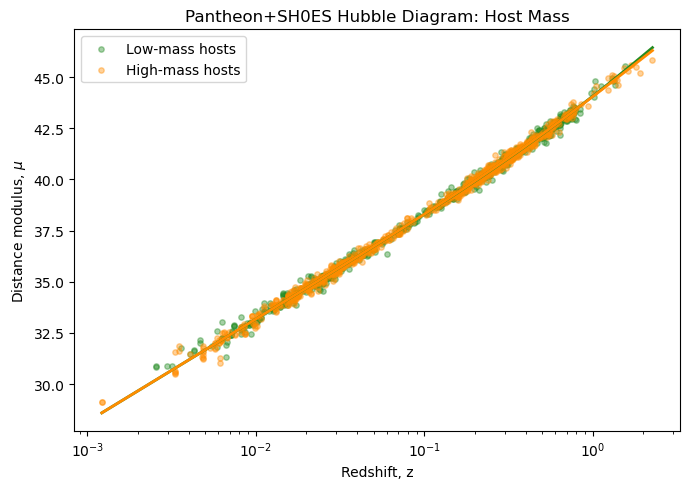

In [35]:
plot_hubble_split(
    low_mass_df_5d,
    high_mass_df_5d,
    low_mass_samples_5d,
    high_mass_samples_5d,
    "Low-mass hosts",
    "High-mass hosts",
    "forestgreen",
    "darkorange",
    "Pantheon+SH0ES Hubble Diagram: Host Mass",
    hubble_dir / "Pantheon+SH0ES_hubble_host_mass.png"
)

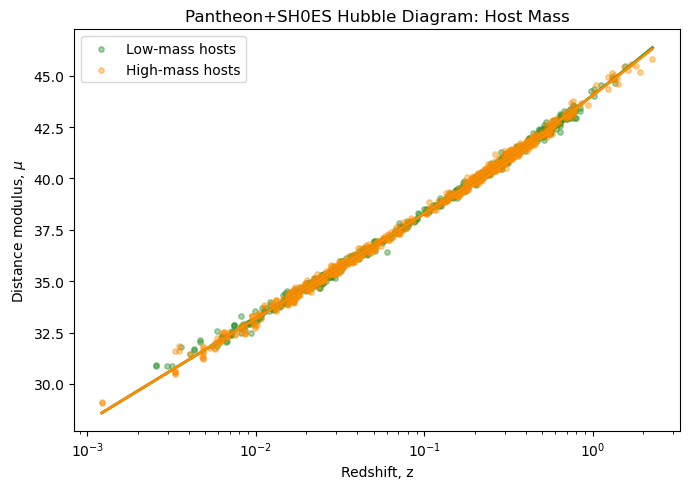

In [36]:
plot_hubble_split(
    clipped_low_mass_df_5d,
    clipped_high_mass_df_5d,
    clipped_low_mass_samples_5d,
    clipped_high_mass_samples_5d,
    "Low-mass hosts",
    "High-mass hosts",
    "forestgreen",
    "darkorange",
    "Pantheon+SH0ES Hubble Diagram: Host Mass",
    hubble_dir / "Pantheon+SH0ES_clipped_hubble_host_mass.png"
)